Extracting video information...
Processed 66 videos successfully
VIDEO DATASET SUMMARY STATISTICS

Total Videos: 66
AI Videos: 33
Real Videos: 33

Class Distribution:
  AI: 33 videos (50.0%)
  REAL: 33 videos (50.0%)

Duration Statistics (seconds):
       count       mean        std       min       25%        50%        75%  \
label                                                                          
ai      33.0  11.529497  10.685065  2.535867  5.133333   8.000000  12.133312   
real    33.0  20.236607  13.049541  2.280000  9.760000  18.051367  27.652625   

         max  
label         
ai     59.80  
real   53.16  

Resolution Statistics:
label  resolution
ai     1280x720       9
       1920x1080      8
       1280x768       3
       640x360        3
       1344x768       2
       3640x2048      2
       854x480        2
       1200x720       1
       1906x1080      1
       2304x1296      1
       655x368        1
real   3840x2160     17
       1920x1080      8
       1280x720 

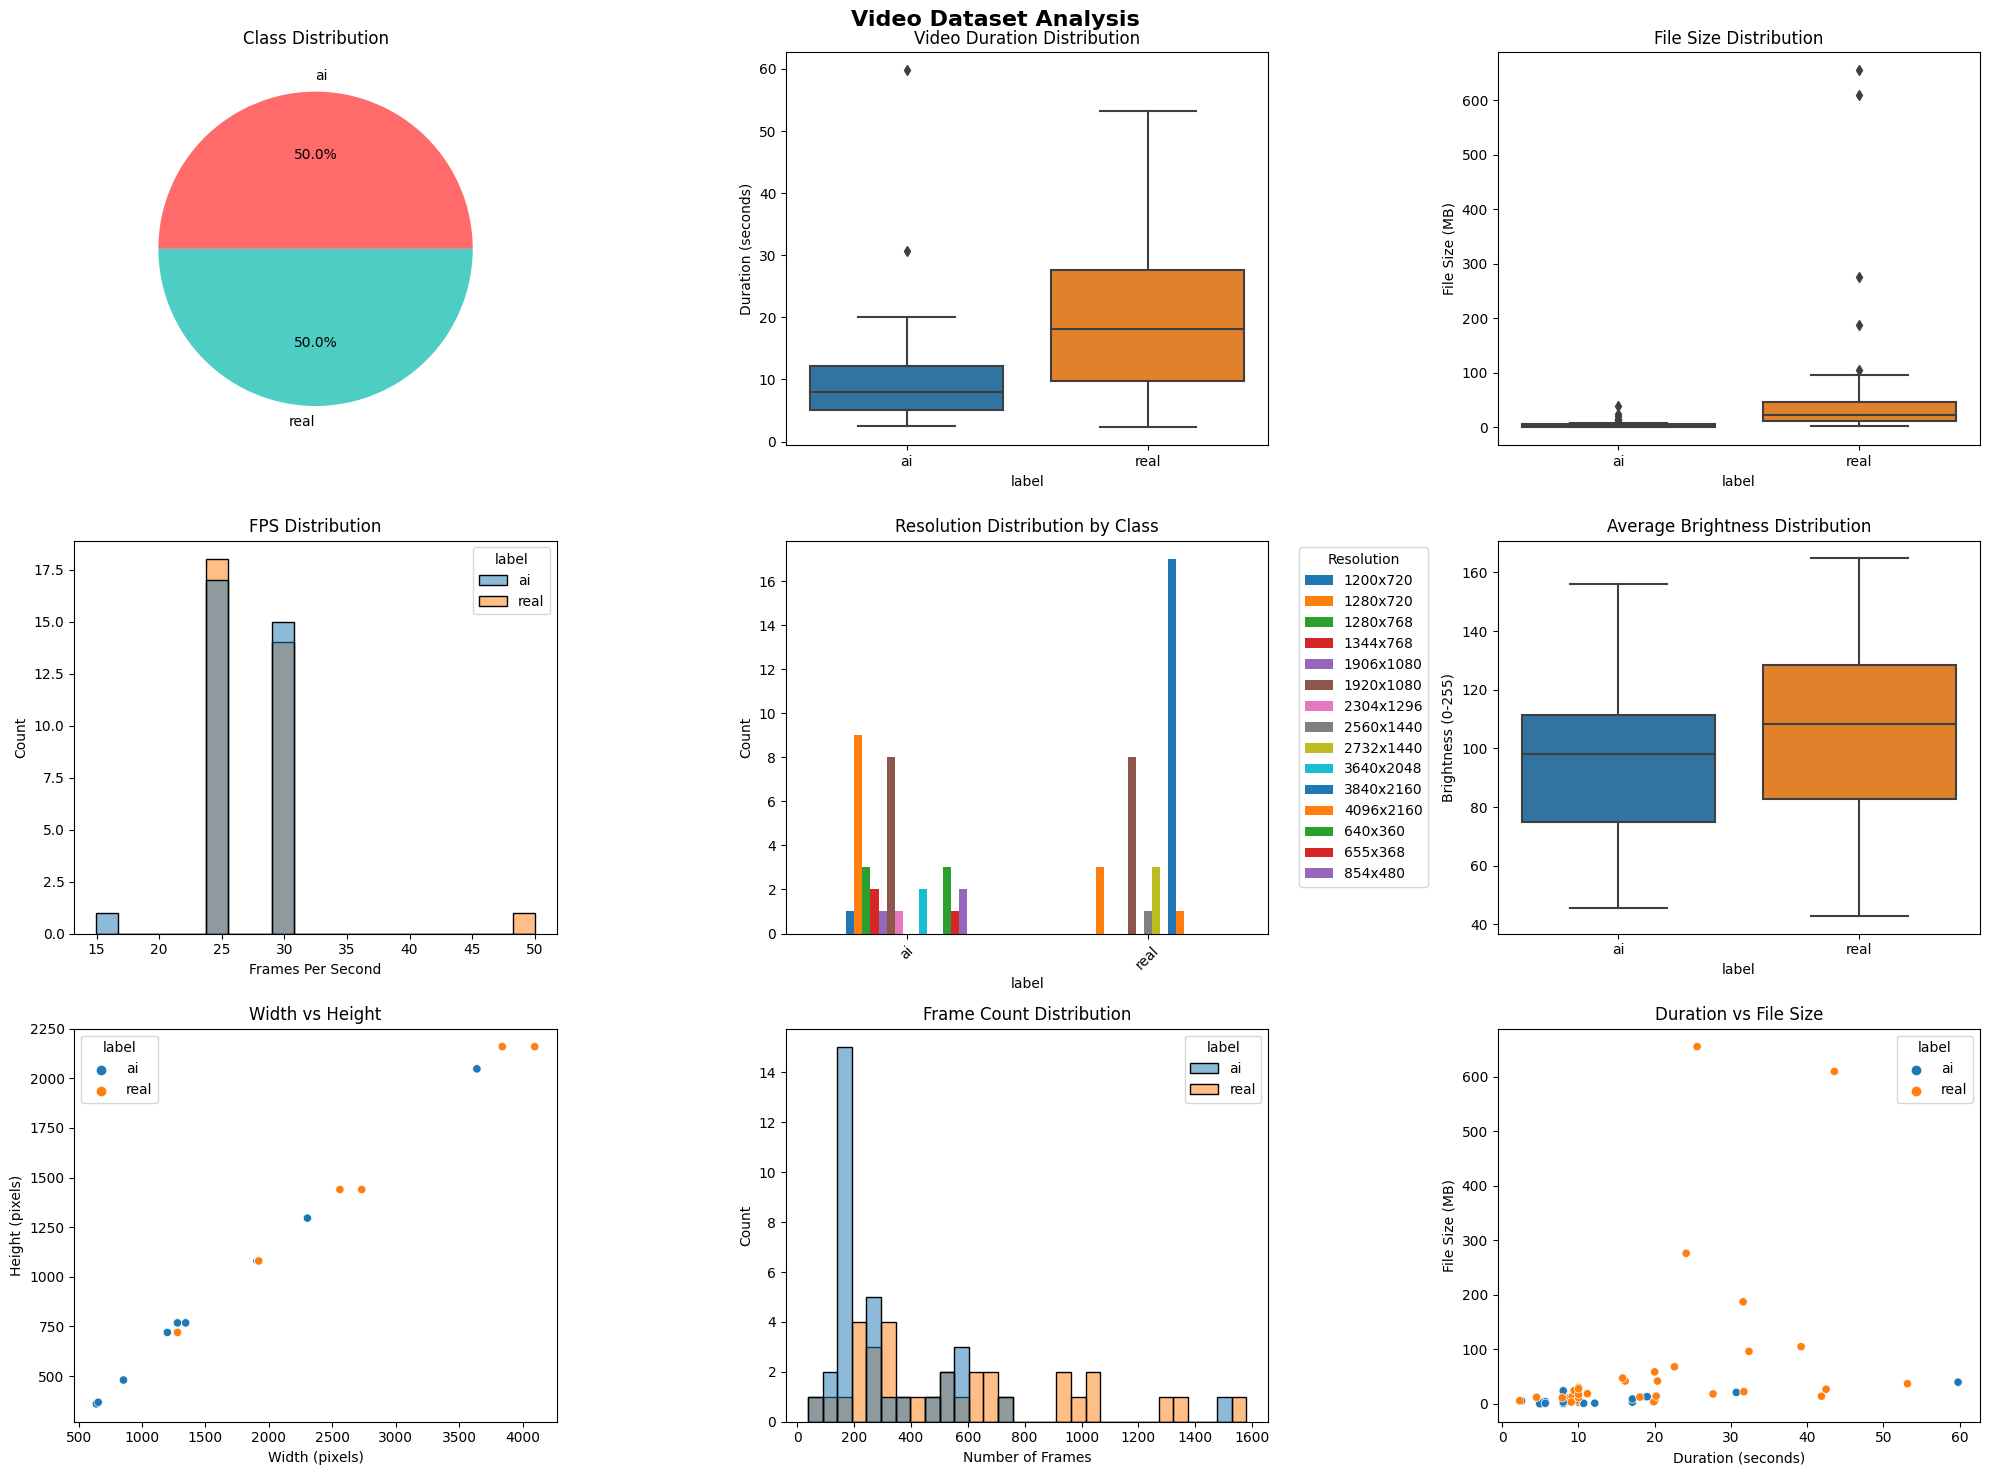

ANOMALY DETECTION REPORT
⚠️  Low FPS videos (< 15): 1
⚠️  Large files (> 100MB): 5
⚠️  Small files (< 1MB): 9
Dataset information saved to video_dataset_info.csv
Sample frames saved to sample_frames/

EDA complete! Check the generated files and plots.


In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

class VideoEDA:
    def __init__(self, dataset_path):
        """
        Initialize the VideoEDA class
        
        Args:
            dataset_path: Path to the dataset containing 'ai' and 'real' folders
        """
        self.dataset_path = dataset_path
        self.video_info = []
        self.ai_folder = os.path.join(dataset_path, 'ai')
        self.real_folder = os.path.join(dataset_path, 'real')
        
    def extract_video_info(self):
        """Extract detailed information from all videos"""
        print("Extracting video information...")
        
        # Process AI videos
        if os.path.exists(self.ai_folder):
            for filename in os.listdir(self.ai_folder):
                if filename.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
                    video_path = os.path.join(self.ai_folder, filename)
                    info = self._get_video_properties(video_path, 'ai', filename)
                    if info:
                        self.video_info.append(info)
        
        # Process Real videos
        if os.path.exists(self.real_folder):
            for filename in os.listdir(self.real_folder):
                if filename.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
                    video_path = os.path.join(self.real_folder, filename)
                    info = self._get_video_properties(video_path, 'real', filename)
                    if info:
                        self.video_info.append(info)
        
        self.df = pd.DataFrame(self.video_info)
        print(f"Processed {len(self.video_info)} videos successfully")
        return self.df
    
    def _get_video_properties(self, video_path, label, filename):
        """Extract properties from a single video"""
        try:
            cap = cv2.VideoCapture(video_path)
            
            if not cap.isOpened():
                print(f"Could not open video: {filename}")
                return None
            
            # Get video properties
            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            duration = frame_count / fps if fps > 0 else 0
            
            # Get file size
            file_size_mb = os.path.getsize(video_path) / (1024 * 1024)
            
            # Calculate aspect ratio
            aspect_ratio = width / height if height > 0 else 0
            
            # Sample a few frames to get brightness info
            brightness_values = []
            cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
            
            # Sample frames at different positions
            sample_positions = [0, frame_count//4, frame_count//2, 3*frame_count//4, frame_count-1]
            
            for pos in sample_positions:
                if pos < frame_count:
                    cap.set(cv2.CAP_PROP_POS_FRAMES, pos)
                    ret, frame = cap.read()
                    if ret:
                        # Convert to grayscale and calculate mean brightness
                        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                        brightness_values.append(np.mean(gray))
            
            avg_brightness = np.mean(brightness_values) if brightness_values else 0
            
            cap.release()
            
            return {
                'filename': filename,
                'label': label,
                'duration_seconds': duration,
                'fps': fps,
                'frame_count': frame_count,
                'width': width,
                'height': height,
                'aspect_ratio': aspect_ratio,
                'resolution': f"{width}x{height}",
                'file_size_mb': file_size_mb,
                'avg_brightness': avg_brightness,
                'video_path': video_path
            }
            
        except Exception as e:
            print(f"Error processing {filename}: {str(e)}")
            return None
    
    def generate_summary_statistics(self):
        """Generate summary statistics for the dataset"""
        if self.df is None or self.df.empty:
            print("No data available. Please run extract_video_info() first.")
            return
        
        print("="*60)
        print("VIDEO DATASET SUMMARY STATISTICS")
        print("="*60)
        
        # Basic count statistics
        print(f"\nTotal Videos: {len(self.df)}")
        print(f"AI Videos: {len(self.df[self.df['label'] == 'ai'])}")
        print(f"Real Videos: {len(self.df[self.df['label'] == 'real'])}")
        
        # Class distribution
        class_dist = self.df['label'].value_counts()
        print(f"\nClass Distribution:")
        for label, count in class_dist.items():
            percentage = (count / len(self.df)) * 100
            print(f"  {label.upper()}: {count} videos ({percentage:.1f}%)")
        
        # Duration statistics
        print(f"\nDuration Statistics (seconds):")
        print(self.df.groupby('label')['duration_seconds'].describe())
        
        # Resolution statistics
        print(f"\nResolution Statistics:")
        resolution_counts = self.df.groupby('label')['resolution'].value_counts()
        print(resolution_counts)
        
        # File size statistics
        print(f"\nFile Size Statistics (MB):")
        print(self.df.groupby('label')['file_size_mb'].describe())
        
        # FPS statistics
        print(f"\nFPS Statistics:")
        print(self.df.groupby('label')['fps'].describe())
        
        return self.df.describe()
    
    def plot_distributions(self, figsize=(20, 15)):
        """Create comprehensive visualization plots"""
        if self.df is None or self.df.empty:
            print("No data available. Please run extract_video_info() first.")
            return
        
        fig, axes = plt.subplots(3, 3, figsize=figsize)
        fig.suptitle('Video Dataset Analysis', fontsize=16, fontweight='bold')
        
        # 1. Class distribution
        class_counts = self.df['label'].value_counts()
        axes[0,0].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', 
                      colors=['#ff6b6b', '#4ecdc4'])
        axes[0,0].set_title('Class Distribution')
        
        # 2. Duration distribution
        sns.boxplot(data=self.df, x='label', y='duration_seconds', ax=axes[0,1])
        axes[0,1].set_title('Video Duration Distribution')
        axes[0,1].set_ylabel('Duration (seconds)')
        
        # 3. File size distribution
        sns.boxplot(data=self.df, x='label', y='file_size_mb', ax=axes[0,2])
        axes[0,2].set_title('File Size Distribution')
        axes[0,2].set_ylabel('File Size (MB)')
        
        # 4. FPS distribution
        sns.histplot(data=self.df, x='fps', hue='label', bins=20, ax=axes[1,0])
        axes[1,0].set_title('FPS Distribution')
        axes[1,0].set_xlabel('Frames Per Second')
        
        # 5. Resolution distribution
        resolution_counts = self.df.groupby(['label', 'resolution']).size().unstack(fill_value=0)
        resolution_counts.plot(kind='bar', ax=axes[1,1], rot=45)
        axes[1,1].set_title('Resolution Distribution by Class')
        axes[1,1].set_ylabel('Count')
        axes[1,1].legend(title='Resolution', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        # 6. Brightness distribution
        sns.boxplot(data=self.df, x='label', y='avg_brightness', ax=axes[1,2])
        axes[1,2].set_title('Average Brightness Distribution')
        axes[1,2].set_ylabel('Brightness (0-255)')
        
        # 7. Aspect ratio distribution
        sns.scatterplot(data=self.df, x='width', y='height', hue='label', ax=axes[2,0])
        axes[2,0].set_title('Width vs Height')
        axes[2,0].set_xlabel('Width (pixels)')
        axes[2,0].set_ylabel('Height (pixels)')
        
        # 8. Frame count distribution
        sns.histplot(data=self.df, x='frame_count', hue='label', bins=30, ax=axes[2,1])
        axes[2,1].set_title('Frame Count Distribution')
        axes[2,1].set_xlabel('Number of Frames')
        
        # 9. Duration vs File Size correlation
        sns.scatterplot(data=self.df, x='duration_seconds', y='file_size_mb', 
                       hue='label', ax=axes[2,2])
        axes[2,2].set_title('Duration vs File Size')
        axes[2,2].set_xlabel('Duration (seconds)')
        axes[2,2].set_ylabel('File Size (MB)')
        
        plt.tight_layout()
        plt.show()
    
    def detect_anomalies(self):
        """Detect potential anomalies or issues in the dataset"""
        if self.df is None or self.df.empty:
            print("No data available. Please run extract_video_info() first.")
            return
        
        print("="*60)
        print("ANOMALY DETECTION REPORT")
        print("="*60)
        
        anomalies = []
        
        # Check for very short videos (< 1 second)
        short_videos = self.df[self.df['duration_seconds'] < 1]
        if not short_videos.empty:
            anomalies.append(f"Found {len(short_videos)} videos shorter than 1 second")
            print(f"⚠️  Short videos (< 1 second): {len(short_videos)}")
            
        # Check for very long videos (> 300 seconds / 5 minutes)
        long_videos = self.df[self.df['duration_seconds'] > 300]
        if not long_videos.empty:
            anomalies.append(f"Found {len(long_videos)} videos longer than 5 minutes")
            print(f"⚠️  Long videos (> 5 minutes): {len(long_videos)}")
            
        # Check for unusual aspect ratios
        unusual_aspect = self.df[(self.df['aspect_ratio'] < 0.5) | (self.df['aspect_ratio'] > 3)]
        if not unusual_aspect.empty:
            anomalies.append(f"Found {len(unusual_aspect)} videos with unusual aspect ratios")
            print(f"⚠️  Unusual aspect ratios: {len(unusual_aspect)}")
            
        # Check for very low FPS
        low_fps = self.df[self.df['fps'] < 15]
        if not low_fps.empty:
            anomalies.append(f"Found {len(low_fps)} videos with FPS < 15")
            print(f"⚠️  Low FPS videos (< 15): {len(low_fps)}")
            
        # Check for very large files
        large_files = self.df[self.df['file_size_mb'] > 100]
        if not large_files.empty:
            anomalies.append(f"Found {len(large_files)} videos larger than 100MB")
            print(f"⚠️  Large files (> 100MB): {len(large_files)}")
            
        # Check for very small files
        small_files = self.df[self.df['file_size_mb'] < 1]
        if not small_files.empty:
            anomalies.append(f"Found {len(small_files)} videos smaller than 1MB")
            print(f"⚠️  Small files (< 1MB): {len(small_files)}")
        
        if not anomalies:
            print("✅ No anomalies detected in the dataset")
        
        return anomalies
    
    def save_dataset_info(self, output_path="dataset_info.csv"):
        """Save the extracted dataset information to CSV"""
        if self.df is None or self.df.empty:
            print("No data available. Please run extract_video_info() first.")
            return
            
        self.df.to_csv(output_path, index=False)
        print(f"Dataset information saved to {output_path}")
    
    def get_sample_frames(self, n_samples=5, output_dir="sample_frames"):
        """Extract sample frames from random videos for visual inspection"""
        if self.df is None or self.df.empty:
            print("No data available. Please run extract_video_info() first.")
            return
            
        os.makedirs(output_dir, exist_ok=True)
        
        # Sample videos from each class
        ai_samples = self.df[self.df['label'] == 'ai'].sample(min(n_samples, len(self.df[self.df['label'] == 'ai'])))
        real_samples = self.df[self.df['label'] == 'real'].sample(min(n_samples, len(self.df[self.df['label'] == 'real'])))
        
        for idx, row in ai_samples.iterrows():
            self._extract_sample_frame(row['video_path'], f"{output_dir}/ai_sample_{idx}.jpg")
            
        for idx, row in real_samples.iterrows():
            self._extract_sample_frame(row['video_path'], f"{output_dir}/real_sample_{idx}.jpg")
            
        print(f"Sample frames saved to {output_dir}/")
    
    def _extract_sample_frame(self, video_path, output_path):
        """Extract a single frame from the middle of a video"""
        try:
            cap = cv2.VideoCapture(video_path)
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            
            # Get frame from the middle of the video
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_count // 2)
            ret, frame = cap.read()
            
            if ret:
                cv2.imwrite(output_path, frame)
            
            cap.release()
        except Exception as e:
            print(f"Error extracting frame from {video_path}: {str(e)}")

# Usage example:
if __name__ == "__main__":
    # Initialize EDA with your dataset path
    dataset_path = "/kaggle/input/realai-video-dataset"  # Update this path
    
    eda = VideoEDA(dataset_path)
    
    # Step 1: Extract video information
    df = eda.extract_video_info()
    
    # Step 2: Generate summary statistics
    eda.generate_summary_statistics()
    
    # Step 3: Create visualizations
    eda.plot_distributions()
    
    # Step 4: Detect anomalies
    anomalies = eda.detect_anomalies()
    
    # Step 5: Save dataset information
    eda.save_dataset_info("video_dataset_info.csv")
    
    # Step 6: Extract sample frames for visual inspection
    eda.get_sample_frames(n_samples=10, output_dir="sample_frames")
    
    print("\nEDA complete! Check the generated files and plots.")

In [5]:
# import os
# import cv2
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
# import tensorflow as tf
# from tensorflow.keras import layers, models, callbacks
# from tensorflow.keras.applications import VGG16, VGG19, ResNet50, InceptionV3
# from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
# from tensorflow.keras.preprocessing.image import img_to_array
# import pickle
# import json
# from datetime import datetime
# import warnings
# warnings.filterwarnings('ignore')

# class AIVideoClassifier:
#     def __init__(self, dataset_path, model_name='vgg16', sequence_length=16):
#         """
#         Complete AI vs Real Video Classification System
        
#         Args:
#             dataset_path: Path to dataset with 'ai' and 'real' folders
#             model_name: CNN backbone ('vgg16', 'vgg19', 'resnet50', 'inceptionv3')
#             sequence_length: Number of frames to extract from each video
#         """
#         self.dataset_path = dataset_path
#         self.model_name = model_name.lower()
#         self.sequence_length = sequence_length
#         self.feature_dim = 512 if 'vgg' in model_name else 2048
#         self.model = None
#         self.cnn_model = None
#         self.history = None
#         self.class_labels = {'ai': 0, 'real': 1}
#         self.reverse_labels = {0: 'ai', 1: 'real'}
        
#         # Create output directories
#         os.makedirs('models', exist_ok=True)
#         os.makedirs('features', exist_ok=True)
#         os.makedirs('plots', exist_ok=True)
#         os.makedirs('heatmaps', exist_ok=True)
        
#     def load_cnn_model(self):
#         """Load pre-trained CNN model for feature extraction"""
#         print(f"Loading {self.model_name} model...")
        
#         if self.model_name == 'vgg16':
#             self.cnn_model = VGG16(weights='imagenet', include_top=False, 
#                                   input_shape=(224, 224, 3))
#         elif self.model_name == 'vgg19':
#             self.cnn_model = VGG19(weights='imagenet', include_top=False, 
#                                   input_shape=(224, 224, 3))
#         elif self.model_name == 'resnet50':
#             self.cnn_model = ResNet50(weights='imagenet', include_top=False, 
#                                      input_shape=(224, 224, 3))
#         elif self.model_name == 'inceptionv3':
#             self.cnn_model = InceptionV3(weights='imagenet', include_top=False, 
#                                         input_shape=(299, 299, 3))
#         else:
#             raise ValueError(f"Unsupported model: {self.model_name}")
            
#         # Add global average pooling
#         x = self.cnn_model.output
#         x = layers.GlobalAveragePooling2D()(x)
#         self.cnn_model = models.Model(self.cnn_model.input, x)
        
#         print(f"CNN model loaded. Feature dimension: {self.cnn_model.output.shape[-1]}")
        
#     def extract_frames_from_video(self, video_path):
#         """Extract uniformly sampled frames from video"""
#         cap = cv2.VideoCapture(video_path)
        
#         if not cap.isOpened():
#             print(f"Error opening video: {video_path}")
#             return None
            
#         frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
#         if frame_count < self.sequence_length:
#             # If video has fewer frames, repeat frames
#             frame_indices = np.linspace(0, frame_count-1, self.sequence_length, dtype=int)
#         else:
#             # Uniformly sample frames
#             frame_indices = np.linspace(0, frame_count-1, self.sequence_length, dtype=int)
        
#         frames = []
#         for idx in frame_indices:
#             cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
#             ret, frame = cap.read()
#             if ret:
#                 # Resize frame based on model requirements
#                 if 'inception' in self.model_name:
#                     frame = cv2.resize(frame, (299, 299))
#                 else:
#                     frame = cv2.resize(frame, (224, 224))
                
#                 frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#                 frames.append(frame)
#             else:
#                 # If frame read fails, duplicate last frame
#                 if frames:
#                     frames.append(frames[-1])
#                 else:
#                     # Create blank frame if no frames read yet
#                     if 'inception' in self.model_name:
#                         blank_frame = np.zeros((299, 299, 3), dtype=np.uint8)
#                     else:
#                         blank_frame = np.zeros((224, 224, 3), dtype=np.uint8)
#                     frames.append(blank_frame)
        
#         cap.release()
#         return np.array(frames)
    
#     def extract_features_from_frames(self, frames):
#         """Extract features from frames using pre-trained CNN"""
#         if frames is None:
#             return None
            
#         # Preprocess frames
#         processed_frames = []
#         for frame in frames:
#             frame_array = img_to_array(frame)
#             frame_array = np.expand_dims(frame_array, axis=0)
            
#             # Apply model-specific preprocessing
#             if 'vgg' in self.model_name:
#                 frame_array = vgg16_preprocess(frame_array)
#             elif self.model_name == 'resnet50':
#                 frame_array = tf.keras.applications.resnet50.preprocess_input(frame_array)
#             elif self.model_name == 'inceptionv3':
#                 frame_array = tf.keras.applications.inception_v3.preprocess_input(frame_array)
                
#             processed_frames.append(frame_array[0])
        
#         processed_frames = np.array(processed_frames)
        
#         # Extract features
#         features = self.cnn_model.predict(processed_frames, verbose=0)
#         return features
    
#     def extract_all_features(self):
#         """Extract features from all videos in the dataset"""
#         print("Starting feature extraction...")
        
#         if self.cnn_model is None:
#             self.load_cnn_model()
        
#         all_features = []
#         all_labels = []
#         video_paths = []
        
#         # Process each class
#         for class_name in ['ai', 'real']:
#             class_path = os.path.join(self.dataset_path, class_name)
            
#             if not os.path.exists(class_path):
#                 print(f"Warning: {class_path} does not exist")
#                 continue
                
#             video_files = [f for f in os.listdir(class_path) 
#                           if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]
            
#             print(f"Processing {len(video_files)} {class_name} videos...")
            
#             for i, video_file in enumerate(video_files):
#                 video_path = os.path.join(class_path, video_file)
                
#                 # Check if features already exist
#                 feature_file = os.path.join('features', f"{class_name}_{video_file}_{self.model_name}.npy")
                
#                 if os.path.exists(feature_file):
#                     features = np.load(feature_file)
#                 else:
#                     # Extract frames
#                     frames = self.extract_frames_from_video(video_path)
#                     if frames is None:
#                         continue
                    
#                     # Extract features
#                     features = self.extract_features_from_frames(frames)
#                     if features is None:
#                         continue
                    
#                     # Save features
#                     np.save(feature_file, features)
                
#                 all_features.append(features)
#                 all_labels.append(self.class_labels[class_name])
#                 video_paths.append(video_path)
                
#                 if (i + 1) % 5 == 0:
#                     print(f"  Processed {i + 1}/{len(video_files)} {class_name} videos")
        
#         print(f"Feature extraction complete. Total videos processed: {len(all_features)}")
        
#         # Convert to numpy arrays
#         X = np.array(all_features)
#         y = np.array(all_labels)
        
#         # Save extracted features
#         np.save('features/X_features.npy', X)
#         np.save('features/y_labels.npy', y)
        
#         with open('features/video_paths.pkl', 'wb') as f:
#             pickle.dump(video_paths, f)
            
#         print(f"Features saved. Shape: {X.shape}")
#         return X, y, video_paths
    
#     def build_lstm_model(self, input_shape):
#         """Build LSTM model with attention mechanism"""
#         inputs = layers.Input(shape=input_shape)
        
#         # Bidirectional LSTM layers
#         lstm1 = layers.Bidirectional(
#             layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)
#         )(inputs)
        
#         lstm2 = layers.Bidirectional(
#             layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)
#         )(lstm1)
        
#         # Attention mechanism
#         attention = layers.Dense(1, activation='tanh')(lstm2)
#         attention = layers.Flatten()(attention)
#         attention = layers.Activation('softmax')(attention)
#         attention = layers.RepeatVector(128)(attention)  # 64*2 for bidirectional
#         attention = layers.Permute([2, 1])(attention)
        
#         # Apply attention
#         sent_representation = layers.Multiply()([lstm2, attention])
#         sent_representation = layers.Lambda(lambda xin: tf.keras.backend.sum(xin, axis=1))(sent_representation)
        
#         # Classification head
#         dense1 = layers.Dense(64, activation='relu')(sent_representation)
#         dropout1 = layers.Dropout(0.5)(dense1)
#         dense2 = layers.Dense(32, activation='relu')(dropout1)
#         dropout2 = layers.Dropout(0.3)(dropout2)
#         outputs = layers.Dense(1, activation='sigmoid')(dropout2)
        
#         model = models.Model(inputs, outputs)
        
#         model.compile(
#             optimizer='adam',
#             loss='binary_crossentropy',
#             metrics=['accuracy', 'precision', 'recall']
#         )
        
#         return model
    
#     def train_model(self, X=None, y=None, test_size=0.2, epochs=50, batch_size=16):
#         """Train the LSTM model"""
        
#         # Load features if not provided
#         if X is None or y is None:
#             if os.path.exists('features/X_features.npy'):
#                 X = np.load('features/X_features.npy')
#                 y = np.load('features/y_labels.npy')
#                 print(f"Loaded features from disk. Shape: {X.shape}")
#             else:
#                 print("No features found. Running feature extraction...")
#                 X, y, _ = self.extract_all_features()
        
#         # Split data
#         X_train, X_test, y_train, y_test = train_test_split(
#             X, y, test_size=test_size, random_state=42, stratify=y
#         )
        
#         print(f"Training set: {X_train.shape[0]} samples")
#         print(f"Test set: {X_test.shape[0]} samples")
        
#         # Build model
#         input_shape = (X.shape[1], X.shape[2])  # (sequence_length, feature_dim)
#         self.model = self.build_lstm_model(input_shape)
        
#         print("Model architecture:")
#         self.model.summary()
        
#         # Callbacks
#         early_stopping = callbacks.EarlyStopping(
#             monitor='val_loss', patience=10, restore_best_weights=True
#         )
        
#         reduce_lr = callbacks.ReduceLROnPlateau(
#             monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7
#         )
        
#         model_checkpoint = callbacks.ModelCheckpoint(
#             f'models/best_model_{self.model_name}.h5',
#             monitor='val_accuracy', save_best_only=True, mode='max'
#         )
        
#         # Train model
#         print("Starting training...")
#         self.history = self.model.fit(
#             X_train, y_train,
#             validation_data=(X_test, y_test),
#             epochs=epochs,
#             batch_size=batch_size,
#             callbacks=[early_stopping, reduce_lr, model_checkpoint],
#             verbose=1
#         )
        
#         # Save final model
#         self.model.save(f'models/final_model_{self.model_name}.h5')
        
#         # Save training history
#         with open(f'models/training_history_{self.model_name}.pkl', 'wb') as f:
#             pickle.dump(self.history.history, f)
        
#         # Save model config
#         config = {
#             'model_name': self.model_name,
#             'sequence_length': self.sequence_length,
#             'feature_dim': self.feature_dim,
#             'class_labels': self.class_labels,
#             'input_shape': input_shape
#         }
        
#         with open(f'models/model_config_{self.model_name}.json', 'w') as f:
#             json.dump(config, f, indent=4)
        
#         print("Training completed!")
#         return self.history
    
#     def evaluate_model(self, X_test=None, y_test=None):
#         """Evaluate model and create comprehensive plots"""
        
#         if X_test is None or y_test is None:
#             # Load data and split
#             X = np.load('features/X_features.npy')
#             y = np.load('features/y_labels.npy')
#             X_train, X_test, y_train, y_test = train_test_split(
#                 X, y, test_size=0.2, random_state=42, stratify=y
#             )
        
#         if self.model is None:
#             # Load best model
#             self.model = models.load_model(f'models/best_model_{self.model_name}.h5')
        
#         # Make predictions
#         y_pred_proba = self.model.predict(X_test)
#         y_pred = (y_pred_proba > 0.5).astype(int).flatten()
#         y_pred_proba = y_pred_proba.flatten()
        
#         # Create comprehensive evaluation plots
#         fig, axes = plt.subplots(2, 3, figsize=(18, 12))
#         fig.suptitle(f'Model Evaluation - {self.model_name.upper()}', fontsize=16, fontweight='bold')
        
#         # 1. Training History
#         if self.history is not None:
#             axes[0,0].plot(self.history.history['loss'], label='Training Loss', linewidth=2)
#             axes[0,0].plot(self.history.history['val_loss'], label='Validation Loss', linewidth=2)
#             axes[0,0].set_title('Training and Validation Loss')
#             axes[0,0].set_xlabel('Epoch')
#             axes[0,0].set_ylabel('Loss')
#             axes[0,0].legend()
#             axes[0,0].grid(True, alpha=0.3)
#         else:
#             # Load history if available
#             try:
#                 with open(f'models/training_history_{self.model_name}.pkl', 'rb') as f:
#                     history = pickle.load(f)
#                 axes[0,0].plot(history['loss'], label='Training Loss', linewidth=2)
#                 axes[0,0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
#                 axes[0,0].set_title('Training and Validation Loss')
#                 axes[0,0].set_xlabel('Epoch')
#                 axes[0,0].set_ylabel('Loss')
#                 axes[0,0].legend()
#                 axes[0,0].grid(True, alpha=0.3)
#             except:
#                 axes[0,0].text(0.5, 0.5, 'Training history not available', 
#                               ha='center', va='center', transform=axes[0,0].transAxes)
        
#         # 2. Accuracy History
#         if self.history is not None:
#             axes[0,1].plot(self.history.history['accuracy'], label='Training Accuracy', linewidth=2)
#             axes[0,1].plot(self.history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
#             axes[0,1].set_title('Training and Validation Accuracy')
#             axes[0,1].set_xlabel('Epoch')
#             axes[0,1].set_ylabel('Accuracy')
#             axes[0,1].legend()
#             axes[0,1].grid(True, alpha=0.3)
#         else:
#             try:
#                 with open(f'models/training_history_{self.model_name}.pkl', 'rb') as f:
#                     history = pickle.load(f)
#                 axes[0,1].plot(history['accuracy'], label='Training Accuracy', linewidth=2)
#                 axes[0,1].plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2)
#                 axes[0,1].set_title('Training and Validation Accuracy')
#                 axes[0,1].set_xlabel('Epoch')
#                 axes[0,1].set_ylabel('Accuracy')
#                 axes[0,1].legend()
#                 axes[0,1].grid(True, alpha=0.3)
#             except:
#                 axes[0,1].text(0.5, 0.5, 'Training history not available', 
#                               ha='center', va='center', transform=axes[0,1].transAxes)
        
#         # 3. Confusion Matrix
#         cm = confusion_matrix(y_test, y_pred)
#         sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,2],
#                    xticklabels=['AI', 'Real'], yticklabels=['AI', 'Real'])
#         axes[0,2].set_title('Confusion Matrix')
#         axes[0,2].set_xlabel('Predicted')
#         axes[0,2].set_ylabel('Actual')
        
#         # 4. ROC Curve
#         fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
#         roc_auc = auc(fpr, tpr)
#         axes[1,0].plot(fpr, tpr, color='darkorange', lw=2, 
#                       label=f'ROC Curve (AUC = {roc_auc:.3f})')
#         axes[1,0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
#         axes[1,0].set_xlim([0.0, 1.0])
#         axes[1,0].set_ylim([0.0, 1.05])
#         axes[1,0].set_xlabel('False Positive Rate')
#         axes[1,0].set_ylabel('True Positive Rate')
#         axes[1,0].set_title('ROC Curve')
#         axes[1,0].legend(loc="lower right")
#         axes[1,0].grid(True, alpha=0.3)
        
#         # 5. Prediction Distribution
#         axes[1,1].hist(y_pred_proba[y_test == 0], bins=20, alpha=0.7, label='AI (True)', color='red')
#         axes[1,1].hist(y_pred_proba[y_test == 1], bins=20, alpha=0.7, label='Real (True)', color='blue')
#         axes[1,1].axvline(x=0.5, color='black', linestyle='--', label='Threshold')
#         axes[1,1].set_xlabel('Prediction Probability')
#         axes[1,1].set_ylabel('Frequency')
#         axes[1,1].set_title('Prediction Distribution')
#         axes[1,1].legend()
#         axes[1,1].grid(True, alpha=0.3)
        
#         # 6. Classification Report as Text
#         cr = classification_report(y_test, y_pred, target_names=['AI', 'Real'], output_dict=True)
#         report_text = f"""
# Classification Report:

# AI:
#   Precision: {cr['AI']['precision']:.3f}
#   Recall: {cr['AI']['recall']:.3f}
#   F1-Score: {cr['AI']['f1-score']:.3f}

# Real:
#   Precision: {cr['Real']['precision']:.3f}
#   Recall: {cr['Real']['recall']:.3f}
#   F1-Score: {cr['Real']['f1-score']:.3f}

# Overall:
#   Accuracy: {cr['accuracy']:.3f}
#   Macro Avg F1: {cr['macro avg']['f1-score']:.3f}
#   Weighted Avg F1: {cr['weighted avg']['f1-score']:.3f}
#         """
        
#         axes[1,2].text(0.1, 0.9, report_text, transform=axes[1,2].transAxes, 
#                       fontfamily='monospace', fontsize=10, verticalalignment='top')
#         axes[1,2].set_xlim(0, 1)
#         axes[1,2].set_ylim(0, 1)
#         axes[1,2].axis('off')
#         axes[1,2].set_title('Classification Report')
        
#         plt.tight_layout()
#         plt.savefig(f'plots/model_evaluation_{self.model_name}.png', dpi=300, bbox_inches='tight')
#         plt.show()
        
#         # Print detailed report
#         print("\n" + "="*50)
#         print("MODEL EVALUATION RESULTS")
#         print("="*50)
#         print(classification_report(y_test, y_pred, target_names=['AI', 'Real']))
#         print(f"ROC AUC Score: {roc_auc:.4f}")
        
#         return {
#             'accuracy': cr['accuracy'],
#             'roc_auc': roc_auc,
#             'classification_report': cr,
#             'predictions': y_pred_proba
#         }
    
#     def predict_single_video(self, video_path, return_heatmap=True):
#         """Predict a single video and optionally generate attention heatmap"""
        
#         if self.model is None:
#             self.model = models.load_model(f'models/best_model_{self.model_name}.h5')
        
#         if self.cnn_model is None:
#             self.load_cnn_model()
        
#         # Extract frames and features
#         frames = self.extract_frames_from_video(video_path)
#         if frames is None:
#             return None
        
#         features = self.extract_features_from_frames(frames)
#         if features is None:
#             return None
        
#         # Make prediction
#         features_input = np.expand_dims(features, axis=0)
#         prediction_proba = self.model.predict(features_input)[0][0]
#         prediction_class = 'real' if prediction_proba > 0.5 else 'ai'
#         confidence = prediction_proba if prediction_proba > 0.5 else 1 - prediction_proba
        
#         result = {
#             'prediction': prediction_class,
#             'confidence': confidence,
#             'probability': prediction_proba,
#             'frames': frames
#         }
        
#         if return_heatmap:
#             heatmap = self.generate_attention_heatmap(features_input, frames, video_path)
#             result['heatmap_path'] = heatmap
        
#         return result
    
#     def generate_attention_heatmap(self, features_input, frames, video_path):
#         """Generate attention heatmap showing which frames contribute most to prediction"""
        
#         # Create a new model that outputs attention weights
#         lstm_layer = None
#         for layer in self.model.layers:
#             if 'bidirectional' in layer.name.lower() and 'lstm' in layer.name.lower():
#                 lstm_layer = layer
#                 break
        
#         if lstm_layer is None:
#             print("Could not find LSTM layer for attention visualization")
#             return None
        
#         # Get intermediate model output
#         intermediate_model = models.Model(
#             inputs=self.model.input,
#             outputs=self.model.get_layer('multiply').output  # attention-weighted features
#         )
        
#         attention_output = intermediate_model.predict(features_input)
        
#         # Calculate attention weights (sum across feature dimensions)
#         attention_weights = np.mean(np.abs(attention_output[0]), axis=1)
#         attention_weights = (attention_weights - attention_weights.min()) / (attention_weights.max() - attention_weights.min())
        
#         # Create heatmap visualization
#         fig, axes = plt.subplots(2, 8, figsize=(20, 6))
#         fig.suptitle(f'Attention Heatmap - {os.path.basename(video_path)}', fontsize=14)
        
#         for i in range(self.sequence_length):
#             row = i // 8
#             col = i % 8
            
#             # Show frame
#             axes[row, col].imshow(frames[i])
#             axes[row, col].set_title(f'Frame {i+1}\nAttention: {attention_weights[i]:.3f}', 
#                                    fontsize=10)
#             axes[row, col].axis('off')
            
#             # Add colored border based on attention weight
#             for spine in axes[row, col].spines.values():
#                 spine.set_edgecolor(plt.cm.Reds(attention_weights[i]))
#                 spine.set_linewidth(4)
        
#         plt.tight_layout()
        
#         # Save heatmap
#         video_name = os.path.splitext(os.path.basename(video_path))[0]
#         heatmap_path = f'heatmaps/attention_heatmap_{video_name}_{self.model_name}.png'
#         plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
#         plt.show()
        
#         return heatmap_path
    
#     def batch_predict(self, video_folder, save_results=True):
#         """Predict multiple videos and save results"""
#         results = []
        
#         video_files = [f for f in os.listdir(video_folder) 
#                       if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]
        
#         print(f"Processing {len(video_files)} videos...")
        
#         for i, video_file in enumerate(video_files):
#             video_path = os.path.join(video_folder, video_file)
#             result = self.predict_single_video(video_path, return_heatmap=False)
            
#             if result:
#                 result['filename'] = video_file
#                 results.append(result)
                
#             if (i + 1) % 5 == 0:
#                 print(f"Processed {i + 1}/{len(video_files)} videos")
        
#         if save_results:
#             # Save results to CSV
#             df_results = pd.DataFrame([
#                 {
#                     'filename': r['filename'],
#                     'prediction': r['prediction'],
#                     'confidence': r['confidence'],
#                     'probability': r['probability']
#                 } for r in results
#             ])
            
#             timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
#             results_path = f'predictions_{self.model_name}_{timestamp}.csv'
#             df_results.to_csv(results_path, index=False)
#             print(f"Results saved to {results_path}")
        
#         return results




# # Usage example


import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16, VGG19, ResNet50, InceptionV3
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.preprocessing.image import img_to_array
import pickle
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class AIVideoClassifier:
    def __init__(self, dataset_path, model_name='vgg16', sequence_length=16):
        """
        Complete AI vs Real Video Classification System
        
        Args:
            dataset_path: Path to dataset with 'ai' and 'real' folders
            model_name: CNN backbone ('vgg16', 'vgg19', 'resnet50', 'inceptionv3')
            sequence_length: Number of frames to extract from each video
        """
        self.dataset_path = dataset_path
        self.model_name = model_name.lower()
        self.sequence_length = sequence_length
        self.feature_dim = 512 if 'vgg' in model_name else 2048
        self.model = None
        self.cnn_model = None
        self.history = None
        self.class_labels = {'ai': 0, 'real': 1}
        self.reverse_labels = {0: 'ai', 1: 'real'}
        
        # Create output directories
        os.makedirs('models', exist_ok=True)
        os.makedirs('features', exist_ok=True)
        os.makedirs('plots', exist_ok=True)
        os.makedirs('heatmaps', exist_ok=True)
        
    def load_cnn_model(self):
        """Load pre-trained CNN model for feature extraction"""
        print(f"Loading {self.model_name} model...")
        
        if self.model_name == 'vgg16':
            self.cnn_model = VGG16(weights='imagenet', include_top=False, 
                                  input_shape=(224, 224, 3))
        elif self.model_name == 'vgg19':
            self.cnn_model = VGG19(weights='imagenet', include_top=False, 
                                  input_shape=(224, 224, 3))
        elif self.model_name == 'resnet50':
            self.cnn_model = ResNet50(weights='imagenet', include_top=False, 
                                     input_shape=(224, 224, 3))
        elif self.model_name == 'inceptionv3':
            self.cnn_model = InceptionV3(weights='imagenet', include_top=False, 
                                        input_shape=(299, 299, 3))
        else:
            raise ValueError(f"Unsupported model: {self.model_name}")
            
        # Add global average pooling
        x = self.cnn_model.output
        x = layers.GlobalAveragePooling2D()(x)
        self.cnn_model = models.Model(self.cnn_model.input, x)
        
        print(f"CNN model loaded. Feature dimension: {self.cnn_model.output.shape[-1]}")
        
    def extract_frames_from_video(self, video_path):
        """Extract uniformly sampled frames from video"""
        cap = cv2.VideoCapture(video_path)
        
        if not cap.isOpened():
            print(f"Error opening video: {video_path}")
            return None
            
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if frame_count < self.sequence_length:
            # If video has fewer frames, repeat frames
            frame_indices = np.linspace(0, frame_count-1, self.sequence_length, dtype=int)
        else:
            # Uniformly sample frames
            frame_indices = np.linspace(0, frame_count-1, self.sequence_length, dtype=int)
        
        frames = []
        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                # Resize frame based on model requirements
                if 'inception' in self.model_name:
                    frame = cv2.resize(frame, (299, 299))
                else:
                    frame = cv2.resize(frame, (224, 224))
                
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame)
            else:
                # If frame read fails, duplicate last frame
                if frames:
                    frames.append(frames[-1])
                else:
                    # Create blank frame if no frames read yet
                    if 'inception' in self.model_name:
                        blank_frame = np.zeros((299, 299, 3), dtype=np.uint8)
                    else:
                        blank_frame = np.zeros((224, 224, 3), dtype=np.uint8)
                    frames.append(blank_frame)
        
        cap.release()
        return np.array(frames)
    
    def extract_features_from_frames(self, frames):
        """Extract features from frames using pre-trained CNN"""
        if frames is None:
            return None
            
        # Preprocess frames
        processed_frames = []
        for frame in frames:
            frame_array = img_to_array(frame)
            frame_array = np.expand_dims(frame_array, axis=0)
            
            # Apply model-specific preprocessing
            if 'vgg' in self.model_name:
                frame_array = vgg16_preprocess(frame_array)
            elif self.model_name == 'resnet50':
                frame_array = tf.keras.applications.resnet50.preprocess_input(frame_array)
            elif self.model_name == 'inceptionv3':
                frame_array = tf.keras.applications.inception_v3.preprocess_input(frame_array)
                
            processed_frames.append(frame_array[0])
        
        processed_frames = np.array(processed_frames)
        
        # Extract features
        features = self.cnn_model.predict(processed_frames, verbose=0)
        return features
    
    def extract_all_features(self):
        """Extract features from all videos in the dataset"""
        print("Starting feature extraction...")
        
        if self.cnn_model is None:
            self.load_cnn_model()
        
        all_features = []
        all_labels = []
        video_paths = []
        
        # Process each class
        for class_name in ['ai', 'real']:
            class_path = os.path.join(self.dataset_path, class_name)
            
            if not os.path.exists(class_path):
                print(f"Warning: {class_path} does not exist")
                continue
                
            video_files = [f for f in os.listdir(class_path) 
                          if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]
            
            print(f"Processing {len(video_files)} {class_name} videos...")
            
            for i, video_file in enumerate(video_files):
                video_path = os.path.join(class_path, video_file)
                
                # Check if features already exist
                feature_file = os.path.join('features', f"{class_name}_{video_file}_{self.model_name}.npy")
                
                if os.path.exists(feature_file):
                    features = np.load(feature_file)
                else:
                    # Extract frames
                    frames = self.extract_frames_from_video(video_path)
                    if frames is None:
                        continue
                    
                    # Extract features
                    features = self.extract_features_from_frames(frames)
                    if features is None:
                        continue
                    
                    # Save features
                    np.save(feature_file, features)
                
                all_features.append(features)
                all_labels.append(self.class_labels[class_name])
                video_paths.append(video_path)
                
                if (i + 1) % 5 == 0:
                    print(f"  Processed {i + 1}/{len(video_files)} {class_name} videos")
        
        print(f"Feature extraction complete. Total videos processed: {len(all_features)}")
        
        # Convert to numpy arrays
        X = np.array(all_features)
        y = np.array(all_labels)
        
        # Save extracted features
        np.save('features/X_features.npy', X)
        np.save('features/y_labels.npy', y)
        
        with open('features/video_paths.pkl', 'wb') as f:
            pickle.dump(video_paths, f)
            
        print(f"Features saved. Shape: {X.shape}")
        return X, y, video_paths
    
    def build_lstm_model(self, input_shape):
        """Build LSTM model with attention mechanism"""
        inputs = layers.Input(shape=input_shape)
        
        # Bidirectional LSTM layers
        lstm1 = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)
        )(inputs)
        
        lstm2 = layers.Bidirectional(
            layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)
        )(lstm1)
        
        # Attention mechanism
        attention = layers.Dense(1, activation='tanh')(lstm2)
        attention = layers.Flatten()(attention)
        attention = layers.Activation('softmax')(attention)
        attention = layers.RepeatVector(128)(attention)  # 64*2 for bidirectional
        attention = layers.Permute([2, 1])(attention)
        
        # Apply attention
        sent_representation = layers.Multiply()([lstm2, attention])
        sent_representation = layers.Lambda(lambda xin: tf.keras.backend.sum(xin, axis=1))(sent_representation)
        
        # Classification head
        dense1 = layers.Dense(64, activation='relu')(sent_representation)
        dropout1 = layers.Dropout(0.5)(dense1)
        dense2 = layers.Dense(32, activation='relu')(dropout1)
        dropout2 = layers.Dropout(0.3)(dense2)
        outputs = layers.Dense(1, activation='sigmoid')(dropout2)
        
        model = models.Model(inputs, outputs)
        
        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy', 'precision', 'recall']
        )
        
        return model
    
    def train_model(self, X=None, y=None, test_size=0.2, epochs=50, batch_size=16):
        """Train the LSTM model"""
        
        # Load features if not provided
        if X is None or y is None:
            if os.path.exists('features/X_features.npy'):
                X = np.load('features/X_features.npy')
                y = np.load('features/y_labels.npy')
                print(f"Loaded features from disk. Shape: {X.shape}")
            else:
                print("No features found. Running feature extraction...")
                X, y, _ = self.extract_all_features()
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )
        
        print(f"Training set: {X_train.shape[0]} samples")
        print(f"Test set: {X_test.shape[0]} samples")
        
        # Build model
        input_shape = (X.shape[1], X.shape[2])  # (sequence_length, feature_dim)
        self.model = self.build_lstm_model(input_shape)
        
        print("Model architecture:")
        self.model.summary()
        
        # Callbacks
        early_stopping = callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True
        )
        
        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7
        )
        
        model_checkpoint = callbacks.ModelCheckpoint(
            f'models/best_model_{self.model_name}.h5',
            monitor='val_accuracy', save_best_only=True, mode='max'
        )
        
        # Train model
        print("Starting training...")
        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stopping, reduce_lr, model_checkpoint],
            verbose=1
        )
        
        # Save final model
        self.model.save(f'models/final_model_{self.model_name}.h5')
        
        # Save training history
        with open(f'models/training_history_{self.model_name}.pkl', 'wb') as f:
            pickle.dump(self.history.history, f)
        
        # Save model config
        config = {
            'model_name': self.model_name,
            'sequence_length': self.sequence_length,
            'feature_dim': self.feature_dim,
            'class_labels': self.class_labels,
            'input_shape': input_shape
        }
        
        with open(f'models/model_config_{self.model_name}.json', 'w') as f:
            json.dump(config, f, indent=4)
        
        print("Training completed!")
        return self.history
    
    def evaluate_model(self, X_test=None, y_test=None):
        """Evaluate model and create comprehensive plots"""
        
        if X_test is None or y_test is None:
            # Load data and split
            X = np.load('features/X_features.npy')
            y = np.load('features/y_labels.npy')
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y
            )
        
        if self.model is None:
            # Load best model
            self.model = models.load_model(f'models/best_model_{self.model_name}.h5')
        
        # Make predictions
        y_pred_proba = self.model.predict(X_test)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()
        y_pred_proba = y_pred_proba.flatten()
        
        # Create comprehensive evaluation plots
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle(f'Model Evaluation - {self.model_name.upper()}', fontsize=16, fontweight='bold')
        
        # 1. Training History
        if self.history is not None:
            axes[0,0].plot(self.history.history['loss'], label='Training Loss', linewidth=2)
            axes[0,0].plot(self.history.history['val_loss'], label='Validation Loss', linewidth=2)
            axes[0,0].set_title('Training and Validation Loss')
            axes[0,0].set_xlabel('Epoch')
            axes[0,0].set_ylabel('Loss')
            axes[0,0].legend()
            axes[0,0].grid(True, alpha=0.3)
        else:
            # Load history if available
            try:
                with open(f'models/training_history_{self.model_name}.pkl', 'rb') as f:
                    history = pickle.load(f)
                axes[0,0].plot(history['loss'], label='Training Loss', linewidth=2)
                axes[0,0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
                axes[0,0].set_title('Training and Validation Loss')
                axes[0,0].set_xlabel('Epoch')
                axes[0,0].set_ylabel('Loss')
                axes[0,0].legend()
                axes[0,0].grid(True, alpha=0.3)
            except:
                axes[0,0].text(0.5, 0.5, 'Training history not available', 
                              ha='center', va='center', transform=axes[0,0].transAxes)
        
        # 2. Accuracy History
        if self.history is not None:
            axes[0,1].plot(self.history.history['accuracy'], label='Training Accuracy', linewidth=2)
            axes[0,1].plot(self.history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
            axes[0,1].set_title('Training and Validation Accuracy')
            axes[0,1].set_xlabel('Epoch')
            axes[0,1].set_ylabel('Accuracy')
            axes[0,1].legend()
            axes[0,1].grid(True, alpha=0.3)
        else:
            try:
                with open(f'models/training_history_{self.model_name}.pkl', 'rb') as f:
                    history = pickle.load(f)
                axes[0,1].plot(history['accuracy'], label='Training Accuracy', linewidth=2)
                axes[0,1].plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2)
                axes[0,1].set_title('Training and Validation Accuracy')
                axes[0,1].set_xlabel('Epoch')
                axes[0,1].set_ylabel('Accuracy')
                axes[0,1].legend()
                axes[0,1].grid(True, alpha=0.3)
            except:
                axes[0,1].text(0.5, 0.5, 'Training history not available', 
                              ha='center', va='center', transform=axes[0,1].transAxes)
        
        # 3. Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,2],
                   xticklabels=['AI', 'Real'], yticklabels=['AI', 'Real'])
        axes[0,2].set_title('Confusion Matrix')
        axes[0,2].set_xlabel('Predicted')
        axes[0,2].set_ylabel('Actual')
        
        # 4. ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        axes[1,0].plot(fpr, tpr, color='darkorange', lw=2, 
                      label=f'ROC Curve (AUC = {roc_auc:.3f})')
        axes[1,0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1,0].set_xlim([0.0, 1.0])
        axes[1,0].set_ylim([0.0, 1.05])
        axes[1,0].set_xlabel('False Positive Rate')
        axes[1,0].set_ylabel('True Positive Rate')
        axes[1,0].set_title('ROC Curve')
        axes[1,0].legend(loc="lower right")
        axes[1,0].grid(True, alpha=0.3)
        
        # 5. Prediction Distribution
        axes[1,1].hist(y_pred_proba[y_test == 0], bins=20, alpha=0.7, label='AI (True)', color='red')
        axes[1,1].hist(y_pred_proba[y_test == 1], bins=20, alpha=0.7, label='Real (True)', color='blue')
        axes[1,1].axvline(x=0.5, color='black', linestyle='--', label='Threshold')
        axes[1,1].set_xlabel('Prediction Probability')
        axes[1,1].set_ylabel('Frequency')
        axes[1,1].set_title('Prediction Distribution')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        # 6. Classification Report as Text
        cr = classification_report(y_test, y_pred, target_names=['AI', 'Real'], output_dict=True)
        report_text = f"""
Classification Report:

AI:
  Precision: {cr['AI']['precision']:.3f}
  Recall: {cr['AI']['recall']:.3f}
  F1-Score: {cr['AI']['f1-score']:.3f}

Real:
  Precision: {cr['Real']['precision']:.3f}
  Recall: {cr['Real']['recall']:.3f}
  F1-Score: {cr['Real']['f1-score']:.3f}

Overall:
  Accuracy: {cr['accuracy']:.3f}
  Macro Avg F1: {cr['macro avg']['f1-score']:.3f}
  Weighted Avg F1: {cr['weighted avg']['f1-score']:.3f}
        """
        
        axes[1,2].text(0.1, 0.9, report_text, transform=axes[1,2].transAxes, 
                      fontfamily='monospace', fontsize=10, verticalalignment='top')
        axes[1,2].set_xlim(0, 1)
        axes[1,2].set_ylim(0, 1)
        axes[1,2].axis('off')
        axes[1,2].set_title('Classification Report')
        
        plt.tight_layout()
        plt.savefig(f'plots/model_evaluation_{self.model_name}.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print detailed report
        print("\n" + "="*50)
        print("MODEL EVALUATION RESULTS")
        print("="*50)
        print(classification_report(y_test, y_pred, target_names=['AI', 'Real']))
        print(f"ROC AUC Score: {roc_auc:.4f}")
        
        return {
            'accuracy': cr['accuracy'],
            'roc_auc': roc_auc,
            'classification_report': cr,
            'predictions': y_pred_proba
        }
    
    def predict_single_video(self, video_path, return_heatmap=True):
        """Predict a single video and optionally generate attention heatmap"""
        
        if self.model is None:
            self.model = models.load_model(f'models/best_model_{self.model_name}.h5')
        
        if self.cnn_model is None:
            self.load_cnn_model()
        
        # Extract frames and features
        frames = self.extract_frames_from_video(video_path)
        if frames is None:
            return None
        
        features = self.extract_features_from_frames(frames)
        if features is None:
            return None
        
        # Make prediction
        features_input = np.expand_dims(features, axis=0)
        prediction_proba = self.model.predict(features_input)[0][0]
        prediction_class = 'real' if prediction_proba > 0.5 else 'ai'
        confidence = prediction_proba if prediction_proba > 0.5 else 1 - prediction_proba
        
        result = {
            'prediction': prediction_class,
            'confidence': confidence,
            'probability': prediction_proba,
            'frames': frames
        }
        
        if return_heatmap:
            heatmap = self.generate_attention_heatmap(features_input, frames, video_path)
            result['heatmap_path'] = heatmap
        
        return result
    
    def generate_attention_heatmap(self, features_input, frames, video_path):
        """Generate attention heatmap showing which frames contribute most to prediction"""
        
        # Create a new model that outputs attention weights
        lstm_layer = None
        for layer in self.model.layers:
            if 'bidirectional' in layer.name.lower() and 'lstm' in layer.name.lower():
                lstm_layer = layer
                break
        
        if lstm_layer is None:
            print("Could not find LSTM layer for attention visualization")
            return None
        
        # Get intermediate model output
        intermediate_model = models.Model(
            inputs=self.model.input,
            outputs=self.model.get_layer('multiply').output  # attention-weighted features
        )
        
        attention_output = intermediate_model.predict(features_input)
        
        # Calculate attention weights (sum across feature dimensions)
        attention_weights = np.mean(np.abs(attention_output[0]), axis=1)
        attention_weights = (attention_weights - attention_weights.min()) / (attention_weights.max() - attention_weights.min())
        
        # Create heatmap visualization
        fig, axes = plt.subplots(2, 8, figsize=(20, 6))
        fig.suptitle(f'Attention Heatmap - {os.path.basename(video_path)}', fontsize=14)
        
        for i in range(self.sequence_length):
            row = i // 8
            col = i % 8
            
            # Show frame
            axes[row, col].imshow(frames[i])
            axes[row, col].set_title(f'Frame {i+1}\nAttention: {attention_weights[i]:.3f}', 
                                   fontsize=10)
            axes[row, col].axis('off')
            
            # Add colored border based on attention weight
            for spine in axes[row, col].spines.values():
                spine.set_edgecolor(plt.cm.Reds(attention_weights[i]))
                spine.set_linewidth(4)
        
        plt.tight_layout()
        
        # Save heatmap
        video_name = os.path.splitext(os.path.basename(video_path))[0]
        heatmap_path = f'heatmaps/attention_heatmap_{video_name}_{self.model_name}.png'
        plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        return heatmap_path
    
    def batch_predict(self, video_folder, save_results=True):
        """Predict multiple videos and save results"""
        results = []
        
        video_files = [f for f in os.listdir(video_folder) 
                      if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]
        
        print(f"Processing {len(video_files)} videos...")
        
        for i, video_file in enumerate(video_files):
            video_path = os.path.join(video_folder, video_file)
            result = self.predict_single_video(video_path, return_heatmap=False)
            
            if result:
                result['filename'] = video_file
                results.append(result)
                
            if (i + 1) % 5 == 0:
                print(f"Processed {i + 1}/{len(video_files)} videos")
        
        if save_results:
            # Save results to CSV
            df_results = pd.DataFrame([
                {
                    'filename': r['filename'],
                    'prediction': r['prediction'],
                    'confidence': r['confidence'],
                    'probability': r['probability']
                } for r in results
            ])
            
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            results_path = f'predictions_{self.model_name}_{timestamp}.csv'
            df_results.to_csv(results_path, index=False)
            print(f"Results saved to {results_path}")
        
        return results



In [6]:

dataset_path = "/kaggle/input/realai-video-dataset"
classifier = AIVideoClassifier(dataset_path, model_name='vgg16', sequence_length=16)

In [3]:

# dataset_path = "/kaggle/input/realai-video-dataset"
# classifier = AIVideoClassifier(dataset_path, model_name='vgg16', sequence_length=16)

print("="*60)
print("AI vs REAL VIDEO CLASSIFICATION PIPELINE")
print("="*60)

# Step 1: Extract features
print("\n1. EXTRACTING FEATURES...")
X, y, video_paths = classifier.extract_all_features()

   

AI vs REAL VIDEO CLASSIFICATION PIPELINE

1. EXTRACTING FEATURES...
Starting feature extraction...
Loading vgg16 model...


I0000 00:00:1756704053.459340      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
CNN model loaded. Feature dimension: 512
Processing 33 ai videos...


I0000 00:00:1756704070.402300     445 service.cc:148] XLA service 0x7dde38085fa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756704070.403314     445 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1756704070.549838     445 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1756704075.337042     445 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Processed 5/33 ai videos
  Processed 10/33 ai videos
  Processed 15/33 ai videos
  Processed 20/33 ai videos
  Processed 25/33 ai videos
  Processed 30/33 ai videos
Processing 33 real videos...
  Processed 5/33 real videos
  Processed 10/33 real videos
  Processed 15/33 real videos
  Processed 20/33 real videos
  Processed 25/33 real videos
  Processed 30/33 real videos
Feature extraction complete. Total videos processed: 66
Features saved. Shape: (66, 16, 512)


In [7]:
 # Step 2: Train model
print("\n2. TRAINING MODEL...")
history = classifier.train_model(X, y, epochs=30, batch_size=8)

   


2. TRAINING MODEL...
Training set: 52 samples
Test set: 14 samples
Model architecture:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 16, 512)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 16, 256)   │    656,384 │ input_layer_2[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 16, 128)   │    164,352 │ bidirectional_2[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16, 1)     │        129 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 16)        │          0 │ flatten_1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 128, 16)   │          0 │ activation_1[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_1 (Permute) │ (None, 16, 128)   │          0 │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 16, 128)   │          0 │ bidirectional_3[… │
│ (Multiply)          │                   │            │ permute_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128)       │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 831,234 (3.17 MB)

 Trainable params: 831,234 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 594ms/step - accuracy: 0.4011 - loss: 0.7138 - precision: 0.4217 - recall: 0.5705 - val_accuracy: 0.5000 - val_loss: 0.7019 - val_precision: 0.5000 - val_recall: 0.7143 - learning_rate: 0.0010
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.4854 - loss: 0.6981 - precision: 0.4386 - recall: 0.5007 - val_accuracy: 0.4286 - val_loss: 0.6938 - val_precision: 0.4286 - val_recall: 0.4286 - learning_rate: 0.0010
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.6044 - loss: 0.6652 - precision: 0.5790 - recall: 0.6868 - val_accuracy: 0.4286 - val_loss: 0.7233 - val_precision: 0.4000 - val_recall: 0.2857 - learning_rate: 0.0010
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.7438 - loss: 0.5787 - precision: 0.6950 - recall: 0.7942 - val_accuracy: 0.5000 - val_loss: 0.7114 - val_precision: 0.5000 - val_recall: 0.2857 - learning_rate: 0.0010
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step 


3. EVALUATING MODEL...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


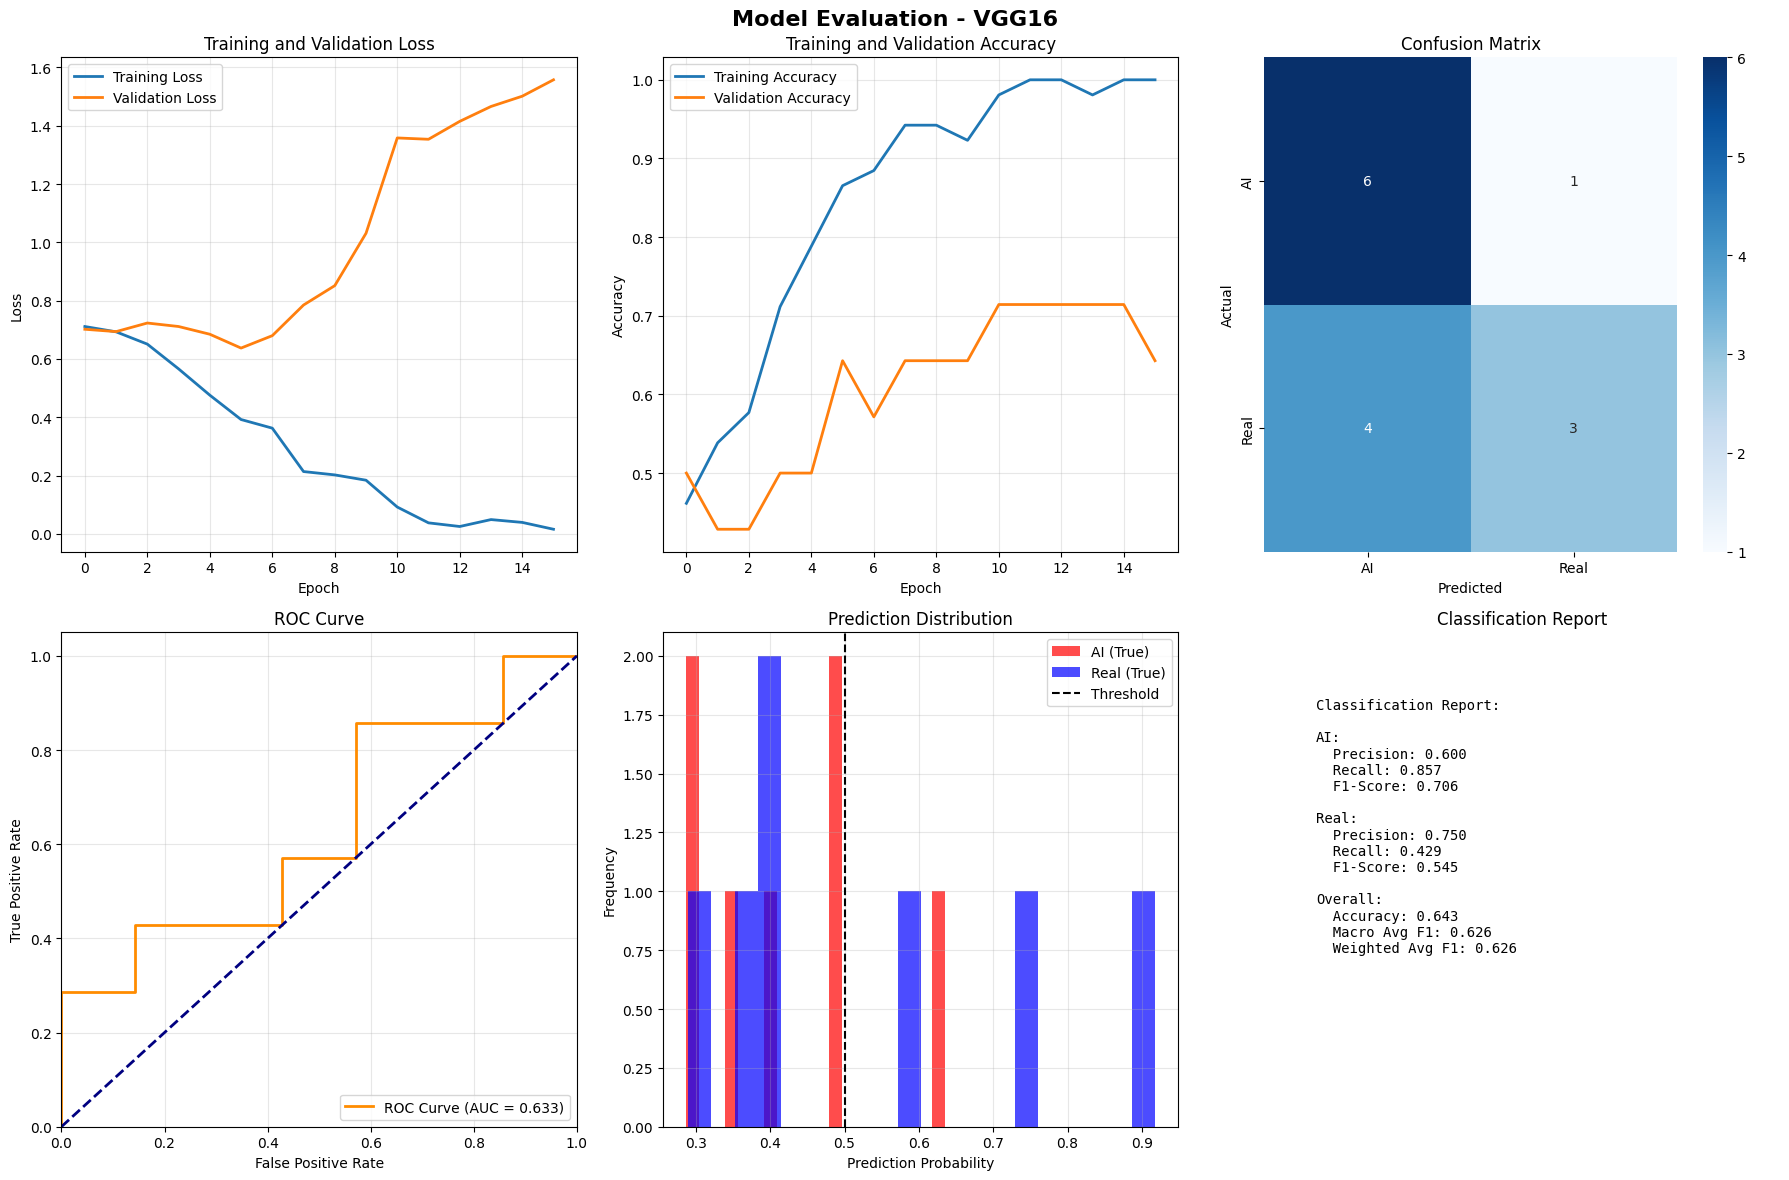


MODEL EVALUATION RESULTS
              precision    recall  f1-score   support

          AI       0.60      0.86      0.71         7
        Real       0.75      0.43      0.55         7

    accuracy                           0.64        14
   macro avg       0.68      0.64      0.63        14
weighted avg       0.67      0.64      0.63        14

ROC AUC Score: 0.6327


In [8]:
 print("\n3. EVALUATING MODEL...")
evaluation_results = classifier.evaluate_model()

In [9]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16, VGG19, ResNet50, InceptionV3, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.regularizers import l2
import pickle
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class ImprovedAIVideoClassifier:
    def __init__(self, dataset_path, model_name='efficientnetb0', sequence_length=32):
        """
        Improved AI vs Real Video Classification System
        
        Improvements:
        1. Longer sequences (32 frames vs 16)
        2. Better CNN backbones (EfficientNet)
        3. Enhanced model architecture
        4. Data augmentation
        5. Better training strategies
        """
        self.dataset_path = dataset_path
        self.model_name = model_name.lower()
        self.sequence_length = sequence_length  # Increased from 16 to 32
        self.model = None
        self.cnn_model = None
        self.history = None
        self.class_labels = {'ai': 0, 'real': 1}
        self.reverse_labels = {0: 'ai', 1: 'real'}
        
        # Create output directories
        os.makedirs('models_improved', exist_ok=True)
        os.makedirs('features_improved', exist_ok=True)
        os.makedirs('plots_improved', exist_ok=True)
        
    def load_improved_cnn_model(self):
        """Load improved CNN model for feature extraction"""
        print(f"Loading {self.model_name} model...")
        
        if self.model_name == 'efficientnetb0':
            self.cnn_model = EfficientNetB0(weights='imagenet', include_top=False, 
                                          input_shape=(224, 224, 3))
        elif self.model_name == 'vgg16':
            self.cnn_model = VGG16(weights='imagenet', include_top=False, 
                                  input_shape=(224, 224, 3))
        elif self.model_name == 'vgg19':
            self.cnn_model = VGG19(weights='imagenet', include_top=False, 
                                  input_shape=(224, 224, 3))
        elif self.model_name == 'resnet50':
            self.cnn_model = ResNet50(weights='imagenet', include_top=False, 
                                     input_shape=(224, 224, 3))
        elif self.model_name == 'inceptionv3':
            self.cnn_model = InceptionV3(weights='imagenet', include_top=False, 
                                        input_shape=(299, 299, 3))
        else:
            raise ValueError(f"Unsupported model: {self.model_name}")
        
        # Add global average pooling
        x = self.cnn_model.output
        x = layers.GlobalAveragePooling2D()(x)
        self.cnn_model = models.Model(self.cnn_model.input, x)
        
        print(f"CNN model loaded. Feature dimension: {self.cnn_model.output.shape[-1]}")
    
    def extract_frames_with_augmentation(self, video_path, augment=False):
        """Extract frames with optional augmentation"""
        cap = cv2.VideoCapture(video_path)
        
        if not cap.isOpened():
            return None
            
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # Sample more frames for better temporal coverage
        if frame_count < self.sequence_length:
            frame_indices = np.linspace(0, frame_count-1, self.sequence_length, dtype=int)
        else:
            # Use different sampling strategies
            if augment and np.random.random() > 0.5:
                # Random sampling for augmentation
                frame_indices = np.sort(np.random.choice(frame_count, self.sequence_length, replace=False))
            else:
                # Uniform sampling
                frame_indices = np.linspace(0, frame_count-1, self.sequence_length, dtype=int)
        
        frames = []
        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                # Resize frame
                if 'inception' in self.model_name:
                    frame = cv2.resize(frame, (299, 299))
                else:
                    frame = cv2.resize(frame, (224, 224))
                
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                
                # Apply augmentation if requested
                if augment:
                    frame = self.augment_frame(frame)
                
                frames.append(frame)
            else:
                if frames:
                    frames.append(frames[-1])
                else:
                    if 'inception' in self.model_name:
                        blank_frame = np.zeros((299, 299, 3), dtype=np.uint8)
                    else:
                        blank_frame = np.zeros((224, 224, 3), dtype=np.uint8)
                    frames.append(blank_frame)
        
        cap.release()
        return np.array(frames)
    
    def augment_frame(self, frame):
        """Apply random augmentations to frame"""
        # Random brightness adjustment
        if np.random.random() > 0.5:
            brightness = np.random.uniform(0.8, 1.2)
            frame = np.clip(frame * brightness, 0, 255).astype(np.uint8)
        
        # Random horizontal flip
        if np.random.random() > 0.5:
            frame = cv2.flip(frame, 1)
        
        # Random rotation
        if np.random.random() > 0.7:
            angle = np.random.uniform(-5, 5)
            center = (frame.shape[1]//2, frame.shape[0]//2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            frame = cv2.warpAffine(frame, M, (frame.shape[1], frame.shape[0]))
        
        return frame
    
    def extract_improved_features(self):
        """Extract features with augmentation"""
        print("Starting improved feature extraction with augmentation...")
        
        if self.cnn_model is None:
            self.load_improved_cnn_model()
        
        all_features = []
        all_labels = []
        video_paths = []
        
        # Process each class
        for class_name in ['ai', 'real']:
            class_path = os.path.join(self.dataset_path, class_name)
            
            if not os.path.exists(class_path):
                continue
                
            video_files = [f for f in os.listdir(class_path) 
                          if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]
            
            print(f"Processing {len(video_files)} {class_name} videos...")
            
            for i, video_file in enumerate(video_files):
                video_path = os.path.join(class_path, video_file)
                
                # Extract original features
                frames = self.extract_frames_with_augmentation(video_path, augment=False)
                if frames is not None:
                    features = self.extract_features_from_frames(frames)
                    if features is not None:
                        all_features.append(features)
                        all_labels.append(self.class_labels[class_name])
                        video_paths.append(video_path)
                
                # Extract augmented features (for training data augmentation)
                for aug_idx in range(2):  # Create 2 augmented versions
                    frames_aug = self.extract_frames_with_augmentation(video_path, augment=True)
                    if frames_aug is not None:
                        features_aug = self.extract_features_from_frames(frames_aug)
                        if features_aug is not None:
                            all_features.append(features_aug)
                            all_labels.append(self.class_labels[class_name])
                            video_paths.append(f"{video_path}_aug_{aug_idx}")
                
                if (i + 1) % 5 == 0:
                    print(f"  Processed {i + 1}/{len(video_files)} {class_name} videos")
        
        X = np.array(all_features)
        y = np.array(all_labels)
        
        # Save improved features
        np.save('features_improved/X_features.npy', X)
        np.save('features_improved/y_labels.npy', y)
        
        print(f"Improved features extracted and saved. Shape: {X.shape}")
        return X, y, video_paths
    
    def extract_features_from_frames(self, frames):
        """Extract features using pre-trained CNN"""
        if frames is None:
            return None
        
        # Preprocess frames
        processed_frames = []
        for frame in frames:
            frame_array = img_to_array(frame)
            frame_array = np.expand_dims(frame_array, axis=0)
            
            # Apply model-specific preprocessing
            if 'efficientnet' in self.model_name:
                frame_array = tf.keras.applications.efficientnet.preprocess_input(frame_array)
            elif 'vgg' in self.model_name:
                frame_array = tf.keras.applications.vgg16.preprocess_input(frame_array)
            elif self.model_name == 'resnet50':
                frame_array = tf.keras.applications.resnet50.preprocess_input(frame_array)
            elif self.model_name == 'inceptionv3':
                frame_array = tf.keras.applications.inception_v3.preprocess_input(frame_array)
                
            processed_frames.append(frame_array[0])
        
        processed_frames = np.array(processed_frames)
        features = self.cnn_model.predict(processed_frames, verbose=0)
        return features
    
    def build_improved_model(self, input_shape):
        """Build improved model architecture with better regularization"""
        inputs = layers.Input(shape=input_shape)
        
        # Multi-scale CNN features processing
        conv1d_1 = layers.Conv1D(64, 3, activation='relu', padding='same')(inputs)
        conv1d_1 = layers.BatchNormalization()(conv1d_1)
        conv1d_1 = layers.Dropout(0.2)(conv1d_1)
        
        conv1d_2 = layers.Conv1D(64, 5, activation='relu', padding='same')(inputs)
        conv1d_2 = layers.BatchNormalization()(conv1d_2)
        conv1d_2 = layers.Dropout(0.2)(conv1d_2)
        
        # Concatenate different kernel sizes
        conv_concat = layers.concatenate([conv1d_1, conv1d_2])
        
        # Bidirectional LSTM layers with different sizes
        lstm1 = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2,
                       kernel_regularizer=l2(0.001))
        )(conv_concat)
        lstm1 = layers.LayerNormalization()(lstm1)
        
        lstm2 = layers.Bidirectional(
            layers.LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2,
                       kernel_regularizer=l2(0.001))
        )(lstm1)
        lstm2 = layers.LayerNormalization()(lstm2)
        
        # Enhanced attention mechanism
        attention_weights = layers.Dense(1, activation='tanh')(lstm2)
        attention_weights = layers.Flatten()(attention_weights)
        attention_weights = layers.Activation('softmax')(attention_weights)
        attention_weights = layers.RepeatVector(128)(attention_weights)
        attention_weights = layers.Permute([2, 1])(attention_weights)
        
        # Apply attention
        attended_lstm = layers.Multiply()([lstm2, attention_weights])
        attended_lstm = layers.Lambda(lambda x: tf.keras.backend.sum(x, axis=1))(attended_lstm)
        
        # Additional features from global statistics
        global_max = layers.GlobalMaxPooling1D()(lstm2)
        global_avg = layers.GlobalAveragePooling1D()(lstm2)
        
        # Combine all features
        combined_features = layers.concatenate([attended_lstm, global_max, global_avg])
        
        # Classification head with residual connection
        dense1 = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(combined_features)
        dense1 = layers.BatchNormalization()(dense1)
        dropout1 = layers.Dropout(0.5)(dense1)
        
        dense2 = layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001))(dropout1)
        dense2 = layers.BatchNormalization()(dense2)
        dropout2 = layers.Dropout(0.4)(dense2)
        
        dense3 = layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001))(dropout2)
        dropout3 = layers.Dropout(0.3)(dense3)
        
        outputs = layers.Dense(1, activation='sigmoid')(dropout3)
        
        model = models.Model(inputs, outputs)
        
        # Use different optimizer with learning rate scheduling
        initial_learning_rate = 0.001
        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate,
            decay_steps=100,
            decay_rate=0.96,
            staircase=True)
        
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999)
        
        model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=['accuracy', 'precision', 'recall']
        )
        
        return model
    
    def train_improved_model(self, X=None, y=None, use_kfold=True, n_splits=5, epochs=100):
        """Train with advanced techniques"""
        
        if X is None or y is None:
            try:
                X = np.load('features_improved/X_features.npy')
                y = np.load('features_improved/y_labels.npy')
            except FileNotFoundError:
                print("Running feature extraction...")
                X, y, _ = self.extract_improved_features()
        
        print(f"Training data shape: {X.shape}")
        print(f"Class distribution: AI={np.sum(y==0)}, Real={np.sum(y==1)}")
        
        if use_kfold:
            # K-Fold Cross Validation for better generalization
            kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            
            fold_scores = []
            best_score = 0
            best_model = None
            
            for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
                print(f"\n--- Training Fold {fold + 1}/{n_splits} ---")
                
                X_train_fold, X_val_fold = X[train_idx], X[val_idx]
                y_train_fold, y_val_fold = y[train_idx], y[val_idx]
                
                # Build model for this fold
                input_shape = (X.shape[1], X.shape[2])
                model_fold = self.build_improved_model(input_shape)
                
                # Enhanced callbacks
                callbacks_list = [
                    callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
                    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7),
                    callbacks.ModelCheckpoint(
                        f'models_improved/fold_{fold}_best.h5',
                        monitor='val_accuracy', save_best_only=True, mode='max'
                    )
                ]
                
                # Train model
                history_fold = model_fold.fit(
                    X_train_fold, y_train_fold,
                    validation_data=(X_val_fold, y_val_fold),
                    epochs=epochs,
                    batch_size=4,  # Smaller batch size for better convergence
                    callbacks=callbacks_list,
                    verbose=1
                )
                
                # Evaluate fold
                val_score = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)[1]  # accuracy
                fold_scores.append(val_score)
                
                print(f"Fold {fold + 1} Validation Accuracy: {val_score:.4f}")
                
                # Keep best model
                if val_score > best_score:
                    best_score = val_score
                    best_model = model_fold
                    self.model = model_fold
                    self.history = history_fold
            
            print(f"\n=== K-Fold Results ===")
            print(f"Average CV Accuracy: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
            print(f"Best Fold Accuracy: {best_score:.4f}")
            
            # Save best model
            best_model.save('models_improved/best_kfold_model.h5')
            
        else:
            # Regular train-validation split
            X_train, X_val, y_train, y_val = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y
            )
            
            input_shape = (X.shape[1], X.shape[2])
            self.model = self.build_improved_model(input_shape)
            
            # Enhanced callbacks
            callbacks_list = [
                callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True),
                callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7),
                callbacks.ModelCheckpoint(
                    'models_improved/best_single_model.h5',
                    monitor='val_accuracy', save_best_only=True, mode='max'
                )
            ]
            
            self.history = self.model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=epochs,
                batch_size=4,
                callbacks=callbacks_list,
                verbose=1
            )
        
        return self.history
    
    def evaluate_improved_model(self):
        """Enhanced evaluation with more metrics"""
        X = np.load('features_improved/X_features.npy')
        y = np.load('features_improved/y_labels.npy')
        
        # Filter out augmented samples for clean evaluation
        original_indices = [i for i, path in enumerate(range(len(y))) if i < len(y)//3]  # Roughly original samples
        
        # Use stratified split for fair evaluation
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        
        if self.model is None:
            self.model = models.load_model('models_improved/best_kfold_model.h5')
        
        # Make predictions
        y_pred_proba = self.model.predict(X_test)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()
        
        # Enhanced visualization
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle('Improved Model Evaluation Results', fontsize=16, fontweight='bold')
        
        # 1. Confusion Matrix with better styling
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
                   xticklabels=['AI', 'Real'], yticklabels=['AI', 'Real'],
                   cbar_kws={'label': 'Count'})
        axes[0,0].set_title('Confusion Matrix')
        
        # 2. ROC Curve
        from sklearn.metrics import roc_curve, auc
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, 
                      label=f'ROC Curve (AUC = {roc_auc:.3f})')
        axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[0,1].set_xlabel('False Positive Rate')
        axes[0,1].set_ylabel('True Positive Rate')
        axes[0,1].set_title('ROC Curve')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        
        # 3. Precision-Recall Curve
        from sklearn.metrics import precision_recall_curve, average_precision_score
        precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
        ap_score = average_precision_score(y_test, y_pred_proba)
        axes[0,2].plot(recall, precision, color='purple', lw=2,
                      label=f'PR Curve (AP = {ap_score:.3f})')
        axes[0,2].set_xlabel('Recall')
        axes[0,2].set_ylabel('Precision')
        axes[0,2].set_title('Precision-Recall Curve')
        axes[0,2].legend()
        axes[0,2].grid(True, alpha=0.3)
        
        # 4. Feature Importance (using attention weights)
        axes[1,0].bar(range(len(y_pred_proba[:20])), y_pred_proba[:20].flatten())
        axes[1,0].set_title('Sample Prediction Probabilities')
        axes[1,0].set_xlabel('Sample Index')
        axes[1,0].set_ylabel('Probability')
        
        # 5. Training History (if available)
        if self.history:
            axes[1,1].plot(self.history.history['accuracy'], label='Training Accuracy')
            axes[1,1].plot(self.history.history['val_accuracy'], label='Validation Accuracy')
            axes[1,1].set_title('Training History')
            axes[1,1].set_xlabel('Epoch')
            axes[1,1].set_ylabel('Accuracy')
            axes[1,1].legend()
            axes[1,1].grid(True, alpha=0.3)
        
        # 6. Error Analysis
        errors = X_test[y_pred != y_test.flatten()]
        if len(errors) > 0:
            axes[1,2].hist([y_pred_proba[y_test.flatten() == 0], 
                           y_pred_proba[y_test.flatten() == 1]], 
                          bins=20, alpha=0.7, label=['AI (True)', 'Real (True)'])
            axes[1,2].set_xlabel('Prediction Probability')
            axes[1,2].set_ylabel('Frequency')
            axes[1,2].set_title('Prediction Distribution')
            axes[1,2].legend()
        
        plt.tight_layout()
        plt.savefig('plots_improved/comprehensive_evaluation.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Detailed report
        from sklearn.metrics import classification_report
        print("\n" + "="*60)
        print("IMPROVED MODEL EVALUATION RESULTS")
        print("="*60)
        print(classification_report(y_test, y_pred, target_names=['AI', 'Real']))
        print(f"ROC AUC Score: {roc_auc:.4f}")
        print(f"Average Precision Score: {ap_score:.4f}")
        
        return {
            'accuracy': np.mean(y_pred == y_test.flatten()),
            'roc_auc': roc_auc,
            'ap_score': ap_score
        }



In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16, VGG19, ResNet50, InceptionV3, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.regularizers import l2
import pickle
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class ImprovedAIVideoClassifier:
    def __init__(self, dataset_path, model_name='efficientnetb0', sequence_length=32):
        """
        Improved AI vs Real Video Classification System
        
        Improvements:
        1. Longer sequences (32 frames vs 16)
        2. Better CNN backbones (EfficientNet)
        3. Enhanced model architecture
        4. Data augmentation
        5. Better training strategies
        """
        self.dataset_path = dataset_path
        self.model_name = model_name.lower()
        self.sequence_length = sequence_length  # Increased from 16 to 32
        self.model = None
        self.cnn_model = None
        self.history = None
        self.class_labels = {'ai': 0, 'real': 1}
        self.reverse_labels = {0: 'ai', 1: 'real'}
        
        # Create output directories
        os.makedirs('models_improved', exist_ok=True)
        os.makedirs('features_improved', exist_ok=True)
        os.makedirs('plots_improved', exist_ok=True)
        
    def load_improved_cnn_model(self):
        """Load improved CNN model for feature extraction"""
        print(f"Loading {self.model_name} model...")
        
        if self.model_name == 'efficientnetb0':
            self.cnn_model = EfficientNetB0(weights='imagenet', include_top=False, 
                                          input_shape=(224, 224, 3))
        elif self.model_name == 'vgg16':
            self.cnn_model = VGG16(weights='imagenet', include_top=False, 
                                  input_shape=(224, 224, 3))
        elif self.model_name == 'vgg19':
            self.cnn_model = VGG19(weights='imagenet', include_top=False, 
                                  input_shape=(224, 224, 3))
        elif self.model_name == 'resnet50':
            self.cnn_model = ResNet50(weights='imagenet', include_top=False, 
                                     input_shape=(224, 224, 3))
        elif self.model_name == 'inceptionv3':
            self.cnn_model = InceptionV3(weights='imagenet', include_top=False, 
                                        input_shape=(299, 299, 3))
        else:
            raise ValueError(f"Unsupported model: {self.model_name}")
        
        # Add global average pooling
        x = self.cnn_model.output
        x = layers.GlobalAveragePooling2D()(x)
        self.cnn_model = models.Model(self.cnn_model.input, x)
        
        print(f"CNN model loaded. Feature dimension: {self.cnn_model.output.shape[-1]}")
    
    def extract_frames_with_augmentation(self, video_path, augment=False):
        """Extract frames with optional augmentation"""
        cap = cv2.VideoCapture(video_path)
        
        if not cap.isOpened():
            return None
            
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # Sample more frames for better temporal coverage
        if frame_count < self.sequence_length:
            frame_indices = np.linspace(0, frame_count-1, self.sequence_length, dtype=int)
        else:
            # Use different sampling strategies
            if augment and np.random.random() > 0.5:
                # Random sampling for augmentation
                frame_indices = np.sort(np.random.choice(frame_count, self.sequence_length, replace=False))
            else:
                # Uniform sampling
                frame_indices = np.linspace(0, frame_count-1, self.sequence_length, dtype=int)
        
        frames = []
        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                # Resize frame
                if 'inception' in self.model_name:
                    frame = cv2.resize(frame, (299, 299))
                else:
                    frame = cv2.resize(frame, (224, 224))
                
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                
                # Apply augmentation if requested
                if augment:
                    frame = self.augment_frame(frame)
                
                frames.append(frame)
            else:
                if frames:
                    frames.append(frames[-1])
                else:
                    if 'inception' in self.model_name:
                        blank_frame = np.zeros((299, 299, 3), dtype=np.uint8)
                    else:
                        blank_frame = np.zeros((224, 224, 3), dtype=np.uint8)
                    frames.append(blank_frame)
        
        cap.release()
        return np.array(frames)
    
    def augment_frame(self, frame):
        """Apply random augmentations to frame"""
        # Random brightness adjustment
        if np.random.random() > 0.5:
            brightness = np.random.uniform(0.8, 1.2)
            frame = np.clip(frame * brightness, 0, 255).astype(np.uint8)
        
        # Random horizontal flip
        if np.random.random() > 0.5:
            frame = cv2.flip(frame, 1)
        
        # Random rotation
        if np.random.random() > 0.7:
            angle = np.random.uniform(-5, 5)
            center = (frame.shape[1]//2, frame.shape[0]//2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            frame = cv2.warpAffine(frame, M, (frame.shape[1], frame.shape[0]))
        
        return frame
    
    def extract_improved_features(self):
        """Extract features with augmentation"""
        print("Starting improved feature extraction with augmentation...")
        
        if self.cnn_model is None:
            self.load_improved_cnn_model()
        
        all_features = []
        all_labels = []
        video_paths = []
        
        # Process each class
        for class_name in ['ai', 'real']:
            class_path = os.path.join(self.dataset_path, class_name)
            
            if not os.path.exists(class_path):
                continue
                
            video_files = [f for f in os.listdir(class_path) 
                          if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]
            
            print(f"Processing {len(video_files)} {class_name} videos...")
            
            for i, video_file in enumerate(video_files):
                video_path = os.path.join(class_path, video_file)
                
                # Extract original features
                frames = self.extract_frames_with_augmentation(video_path, augment=False)
                if frames is not None:
                    features = self.extract_features_from_frames(frames)
                    if features is not None:
                        all_features.append(features)
                        all_labels.append(self.class_labels[class_name])
                        video_paths.append(video_path)
                
                # Extract augmented features (for training data augmentation)
                for aug_idx in range(2):  # Create 2 augmented versions
                    frames_aug = self.extract_frames_with_augmentation(video_path, augment=True)
                    if frames_aug is not None:
                        features_aug = self.extract_features_from_frames(frames_aug)
                        if features_aug is not None:
                            all_features.append(features_aug)
                            all_labels.append(self.class_labels[class_name])
                            video_paths.append(f"{video_path}_aug_{aug_idx}")
                
                if (i + 1) % 5 == 0:
                    print(f"  Processed {i + 1}/{len(video_files)} {class_name} videos")
        
        X = np.array(all_features)
        y = np.array(all_labels)
        
        # Save improved features
        np.save('features_improved/X_features.npy', X)
        np.save('features_improved/y_labels.npy', y)
        
        print(f"Improved features extracted and saved. Shape: {X.shape}")
        return X, y, video_paths
    
    def extract_features_from_frames(self, frames):
        """Extract features using pre-trained CNN"""
        if frames is None:
            return None
        
        # Preprocess frames
        processed_frames = []
        for frame in frames:
            frame_array = img_to_array(frame)
            frame_array = np.expand_dims(frame_array, axis=0)
            
            # Apply model-specific preprocessing
            if 'efficientnet' in self.model_name:
                frame_array = tf.keras.applications.efficientnet.preprocess_input(frame_array)
            elif 'vgg' in self.model_name:
                frame_array = tf.keras.applications.vgg16.preprocess_input(frame_array)
            elif self.model_name == 'resnet50':
                frame_array = tf.keras.applications.resnet50.preprocess_input(frame_array)
            elif self.model_name == 'inceptionv3':
                frame_array = tf.keras.applications.inception_v3.preprocess_input(frame_array)
                
            processed_frames.append(frame_array[0])
        
        processed_frames = np.array(processed_frames)
        features = self.cnn_model.predict(processed_frames, verbose=0)
        return features
    
    def build_improved_model(self, input_shape):
        """Build improved model architecture with better regularization"""
        inputs = layers.Input(shape=input_shape)
        
        # Multi-scale CNN features processing
        conv1d_1 = layers.Conv1D(64, 3, activation='relu', padding='same')(inputs)
        conv1d_1 = layers.BatchNormalization()(conv1d_1)
        conv1d_1 = layers.Dropout(0.2)(conv1d_1)
        
        conv1d_2 = layers.Conv1D(64, 5, activation='relu', padding='same')(inputs)
        conv1d_2 = layers.BatchNormalization()(conv1d_2)
        conv1d_2 = layers.Dropout(0.2)(conv1d_2)
        
        # Concatenate different kernel sizes
        conv_concat = layers.concatenate([conv1d_1, conv1d_2])
        
        # Bidirectional LSTM layers with different sizes
        lstm1 = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2,
                       kernel_regularizer=l2(0.001))
        )(conv_concat)
        lstm1 = layers.LayerNormalization()(lstm1)
        
        lstm2 = layers.Bidirectional(
            layers.LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2,
                       kernel_regularizer=l2(0.001))
        )(lstm1)
        lstm2 = layers.LayerNormalization()(lstm2)
        
        # Enhanced attention mechanism
        attention_weights = layers.Dense(1, activation='tanh')(lstm2)
        attention_weights = layers.Flatten()(attention_weights)
        attention_weights = layers.Activation('softmax')(attention_weights)
        attention_weights = layers.RepeatVector(128)(attention_weights)
        attention_weights = layers.Permute([2, 1])(attention_weights)
        
        # Apply attention
        attended_lstm = layers.Multiply()([lstm2, attention_weights])
        attended_lstm = layers.Lambda(lambda x: tf.keras.backend.sum(x, axis=1))(attended_lstm)
        
        # Additional features from global statistics
        global_max = layers.GlobalMaxPooling1D()(lstm2)
        global_avg = layers.GlobalAveragePooling1D()(lstm2)
        
        # Combine all features
        combined_features = layers.concatenate([attended_lstm, global_max, global_avg])
        
        # Classification head with residual connection
        dense1 = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(combined_features)
        dense1 = layers.BatchNormalization()(dense1)
        dropout1 = layers.Dropout(0.5)(dense1)
        
        dense2 = layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001))(dropout1)
        dense2 = layers.BatchNormalization()(dense2)
        dropout2 = layers.Dropout(0.4)(dense2)
        
        dense3 = layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001))(dropout2)
        dropout3 = layers.Dropout(0.3)(dense3)
        
        outputs = layers.Dense(1, activation='sigmoid')(dropout3)
        
        model = models.Model(inputs, outputs)
        
        # Use different optimizer with learning rate scheduling
        initial_learning_rate = 0.001
        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate,
            decay_steps=100,
            decay_rate=0.96,
            staircase=True)
        
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999)
        
        model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=['accuracy', 'precision', 'recall']
        )
        
        return model
    
    def train_improved_model(self, X=None, y=None, use_kfold=True, n_splits=5, epochs=100):
        """Train with advanced techniques"""
        
        if X is None or y is None:
            try:
                X = np.load('features_improved/X_features.npy')
                y = np.load('features_improved/y_labels.npy')
            except FileNotFoundError:
                print("Running feature extraction...")
                X, y, _ = self.extract_improved_features()
        
        print(f"Training data shape: {X.shape}")
        print(f"Class distribution: AI={np.sum(y==0)}, Real={np.sum(y==1)}")
        
        if use_kfold:
            # K-Fold Cross Validation for better generalization
            kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            
            fold_scores = []
            best_score = 0
            best_model = None
            
            for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
                print(f"\n--- Training Fold {fold + 1}/{n_splits} ---")
                
                X_train_fold, X_val_fold = X[train_idx], X[val_idx]
                y_train_fold, y_val_fold = y[train_idx], y[val_idx]
                
                # Build model for this fold
                input_shape = (X.shape[1], X.shape[2])
                model_fold = self.build_improved_model(input_shape)
                
                # Enhanced callbacks
                callbacks_list = [
                    callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
                    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7),
                    callbacks.ModelCheckpoint(
                        f'models_improved/fold_{fold}_best.h5',
                        monitor='val_accuracy', save_best_only=True, mode='max'
                    )
                ]
                
                # Train model
                history_fold = model_fold.fit(
                    X_train_fold, y_train_fold,
                    validation_data=(X_val_fold, y_val_fold),
                    epochs=epochs,
                    batch_size=4,  # Smaller batch size for better convergence
                    callbacks=callbacks_list,
                    verbose=1
                )
                
                # Evaluate fold
                val_score = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)[1]  # accuracy
                fold_scores.append(val_score)
                
                print(f"Fold {fold + 1} Validation Accuracy: {val_score:.4f}")
                
                # Keep best model
                if val_score > best_score:
                    best_score = val_score
                    best_model = model_fold
                    self.model = model_fold
                    self.history = history_fold
            
            print(f"\n=== K-Fold Results ===")
            print(f"Average CV Accuracy: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
            print(f"Best Fold Accuracy: {best_score:.4f}")
            
            # Save best model
            best_model.save('models_improved/best_kfold_model.h5')
            
        else:
            # Regular train-validation split
            X_train, X_val, y_train, y_val = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y
            )
            
            input_shape = (X.shape[1], X.shape[2])
            self.model = self.build_improved_model(input_shape)
            
            # Enhanced callbacks
            callbacks_list = [
                callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True),
                callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7),
                callbacks.ModelCheckpoint(
                    'models_improved/best_single_model.h5',
                    monitor='val_accuracy', save_best_only=True, mode='max'
                )
            ]
            
            self.history = self.model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=epochs,
                batch_size=4,
                callbacks=callbacks_list,
                verbose=1
            )
        
        return self.history
    
    def evaluate_improved_model(self):
        """Enhanced evaluation with more metrics"""
        X = np.load('features_improved/X_features.npy')
        y = np.load('features_improved/y_labels.npy')
        
        # Filter out augmented samples for clean evaluation
        original_indices = [i for i, path in enumerate(range(len(y))) if i < len(y)//3]  # Roughly original samples
        
        # Use stratified split for fair evaluation
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        
        if self.model is None:
            self.model = models.load_model('models_improved/best_kfold_model.h5')
        
        # Make predictions
        y_pred_proba = self.model.predict(X_test)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()
        
        # Enhanced visualization
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle('Improved Model Evaluation Results', fontsize=16, fontweight='bold')
        
        # 1. Confusion Matrix with better styling
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
                   xticklabels=['AI', 'Real'], yticklabels=['AI', 'Real'],
                   cbar_kws={'label': 'Count'})
        axes[0,0].set_title('Confusion Matrix')
        
        # 2. ROC Curve
        from sklearn.metrics import roc_curve, auc
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, 
                      label=f'ROC Curve (AUC = {roc_auc:.3f})')
        axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[0,1].set_xlabel('False Positive Rate')
        axes[0,1].set_ylabel('True Positive Rate')
        axes[0,1].set_title('ROC Curve')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        
        # 3. Precision-Recall Curve
        from sklearn.metrics import precision_recall_curve, average_precision_score
        precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
        ap_score = average_precision_score(y_test, y_pred_proba)
        axes[0,2].plot(recall, precision, color='purple', lw=2,
                      label=f'PR Curve (AP = {ap_score:.3f})')
        axes[0,2].set_xlabel('Recall')
        axes[0,2].set_ylabel('Precision')
        axes[0,2].set_title('Precision-Recall Curve')
        axes[0,2].legend()
        axes[0,2].grid(True, alpha=0.3)
        
        # 4. Feature Importance (using attention weights)
        axes[1,0].bar(range(len(y_pred_proba[:20])), y_pred_proba[:20].flatten())
        axes[1,0].set_title('Sample Prediction Probabilities')
        axes[1,0].set_xlabel('Sample Index')
        axes[1,0].set_ylabel('Probability')
        
        # 5. Training History (if available)
        if self.history:
            axes[1,1].plot(self.history.history['accuracy'], label='Training Accuracy')
            axes[1,1].plot(self.history.history['val_accuracy'], label='Validation Accuracy')
            axes[1,1].set_title('Training History')
            axes[1,1].set_xlabel('Epoch')
            axes[1,1].set_ylabel('Accuracy')
            axes[1,1].legend()
            axes[1,1].grid(True, alpha=0.3)
        
        # 6. Error Analysis
        errors = X_test[y_pred != y_test.flatten()]
        if len(errors) > 0:
            axes[1,2].hist([y_pred_proba[y_test.flatten() == 0], 
                           y_pred_proba[y_test.flatten() == 1]], 
                          bins=20, alpha=0.7, label=['AI (True)', 'Real (True)'])
            axes[1,2].set_xlabel('Prediction Probability')
            axes[1,2].set_ylabel('Frequency')
            axes[1,2].set_title('Prediction Distribution')
            axes[1,2].legend()
        
        plt.tight_layout()
        plt.savefig('plots_improved/comprehensive_evaluation.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Detailed report
        from sklearn.metrics import classification_report
        print("\n" + "="*60)
        print("IMPROVED MODEL EVALUATION RESULTS")
        print("="*60)
        print(classification_report(y_test, y_pred, target_names=['AI', 'Real']))
        print(f"ROC AUC Score: {roc_auc:.4f}")
        print(f"Average Precision Score: {ap_score:.4f}")
        
        return {
            'accuracy': np.mean(y_pred == y_test.flatten()),
            'roc_auc': roc_auc,
            'ap_score': ap_score
        }

# Usage Instructions


In [10]:
classifier = ImprovedAIVideoClassifier(
    "/kaggle/input/realai-video-dataset", 
    model_name='efficientnetb0',  # Better backbone
    sequence_length=32           # More frames
)


In [11]:
X, y, _ = classifier.extract_improved_features()

Starting improved feature extraction with augmentation...
Loading efficientnetb0 model...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
CNN model loaded. Feature dimension: 1280
Processing 33 ai videos...
  Processed 5/33 ai videos
  Processed 10/33 ai videos
  Processed 15/33 ai videos
  Processed 20/33 ai videos
  Processed 25/33 ai videos
  Processed 30/33 ai videos
Processing 33 real videos...
  Processed 5/33 real videos
  Processed 10/33 real videos
  Processed 15/33 real videos
  Processed 20/33 real videos
  Processed 25/33 real videos
  Processed 30/33 real videos
Improved features extracted and saved. Shape: (198, 32, 1280)


In [12]:
history = classifier.train_improved_model(X, y, use_kfold=True, epochs=100)

Training data shape: (198, 32, 1280)
Class distribution: AI=99, Real=99

--- Training Fold 1/5 ---
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 40s 356ms/step - accuracy: 0.5455 - loss: 2.4221 - precision: 0.6784 - recall: 0.3511 - val_accuracy: 0.6000 - val_loss: 2.1635 - val_precision: 0.7000 - val_recall: 0.3500 - learning_rate: 0.0010
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 291ms/step - accuracy: 0.5595 - loss: 2.3254 - precision: 0.5948 - recall: 0.4493 - val_accuracy: 0.6750 - val_loss: 2.0813 - val_precision: 0.6296 - val_recall: 0.8500 - learning_rate: 0.0010
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 292ms/step - accuracy: 0.6739 - loss: 2.0529 - precision: 0.7382 - recall: 0.6202 - val_accuracy: 0.7750 - val_loss: 1.9874 - val_precision: 0.7037 - val_recall: 0.9500 - learning_rate: 9.6000e-04
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 292ms/step - accuracy: 0.6991 - loss: 2.0944 - precision: 0.7234 - recall: 0.7123 - val_accuracy: 0.8750 - val_loss: 1.8667 - val_precision: 0.826

TypeError: This optimizer was created with a `LearningRateSchedule` object as its `learning_rate` constructor argument, hence its learning rate is not settable. If you need the learning rate to be settable, you should instantiate the optimizer with a float `learning_rate` argument.

📂 Loading feature data...
Total data loaded: 198 samples
Original distribution: AI=99, Real=99
🔄 Creating balanced test set...
Available samples: AI=99, Real=99
✅ Balanced test set created:
   Train: AI=69, Real=69
   Test:  AI=30, Real=30
🚀 LOADING MODEL FROM /kaggle/working/models_improved/fold_0_best.h5
🔄 Building new model and loading weights...
✅ Model loaded successfully!

🔮 Making predictions on balanced test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step

🎉 BALANCED MODEL EVALUATION RESULTS
📊 Accuracy:  0.9833 (98.3%)
📈 ROC AUC:   1.0000

📋 Classification Report:
              precision    recall  f1-score   support

          AI       0.97      1.00      0.98        30
        Real       1.00      0.97      0.98        30

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60


🔍 Confusion Matrix:
    Predicted:
       AI  Real
AI   [ 30   0]  Actual
Real [  1  29]

🔍 SAMPLE

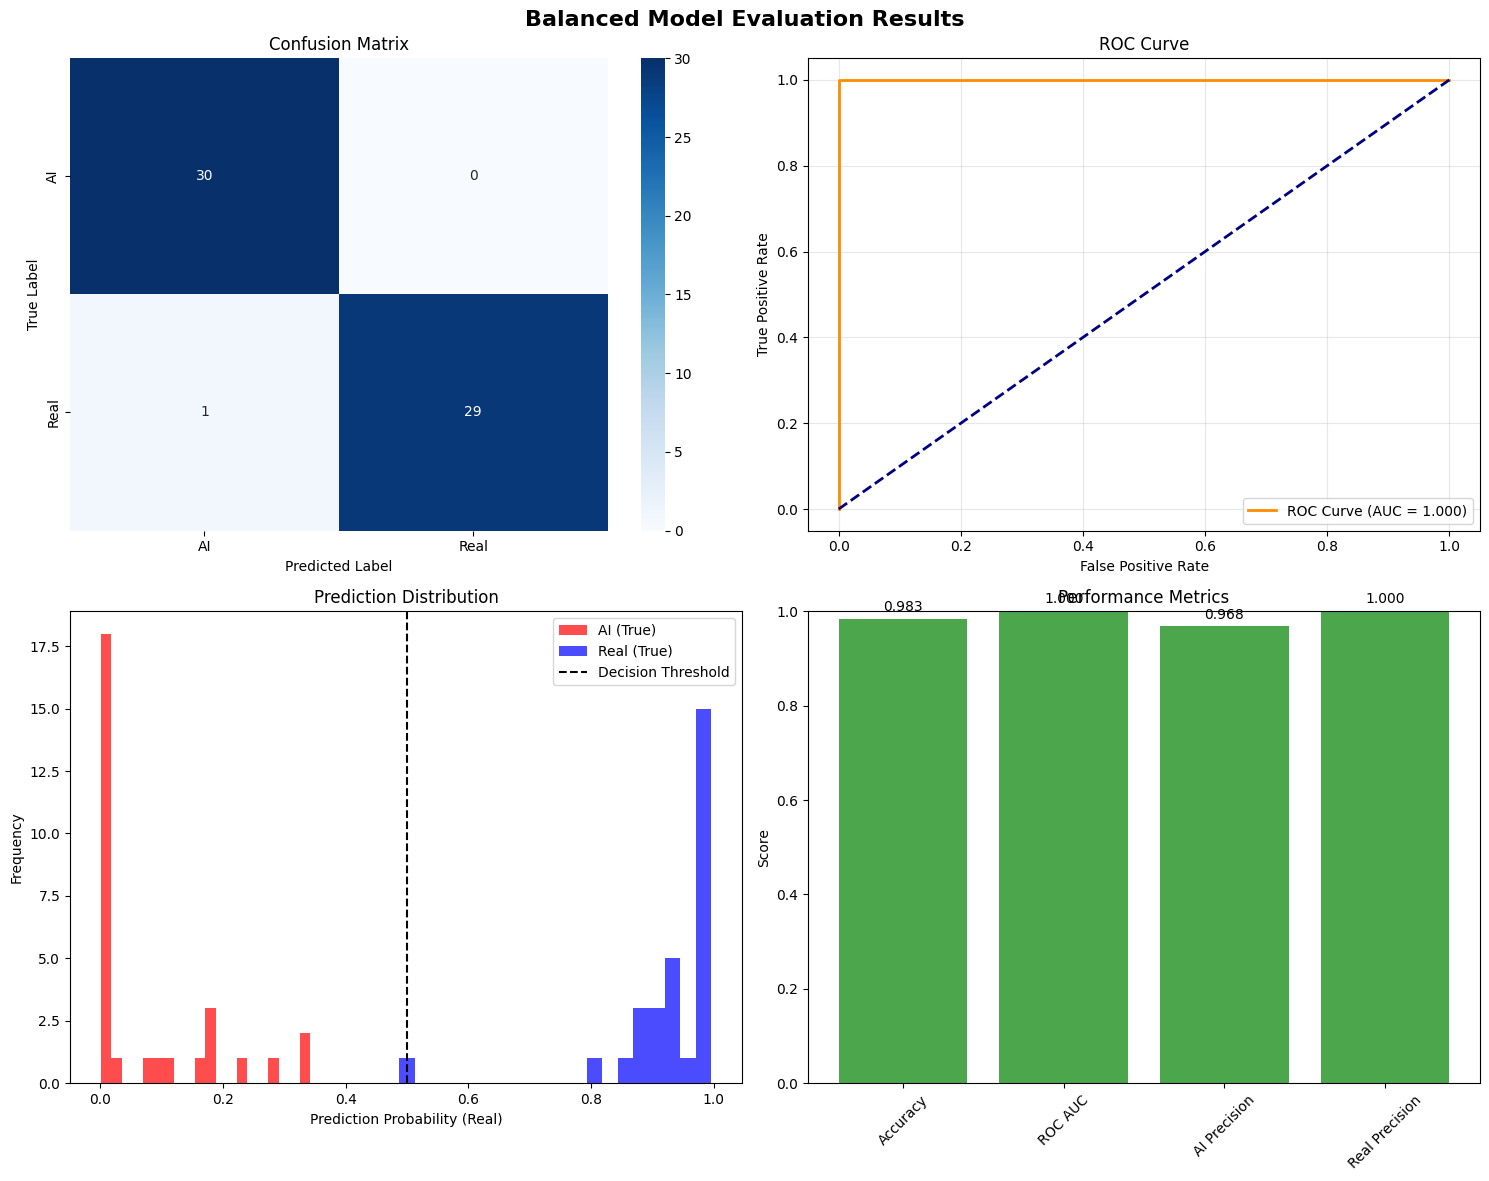

In [20]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class BalancedModelEvaluator:
    """Fixed evaluation system with balanced test sets"""
    
    def __init__(self):
        self.model = None
        
    def create_balanced_test_set(self, X, y, test_size=60, random_state=42):
        """Create a balanced test set with equal AI and Real samples"""
        
        print("🔄 Creating balanced test set...")
        
        # Get indices for each class
        ai_indices = np.where(y == 0)[0]
        real_indices = np.where(y == 1)[0]
        
        print(f"Available samples: AI={len(ai_indices)}, Real={len(real_indices)}")
        
        # Calculate samples per class for balanced test set
        samples_per_class = test_size // 2
        
        if len(ai_indices) < samples_per_class:
            print(f"⚠️  Warning: Only {len(ai_indices)} AI samples available, using all of them")
            samples_per_class = min(len(ai_indices), len(real_indices))
        
        if len(real_indices) < samples_per_class:
            print(f"⚠️  Warning: Only {len(real_indices)} Real samples available, using all of them")
            samples_per_class = min(len(ai_indices), len(real_indices))
        
        # Randomly sample from each class
        np.random.seed(random_state)
        
        selected_ai = np.random.choice(ai_indices, samples_per_class, replace=False)
        selected_real = np.random.choice(real_indices, samples_per_class, replace=False)
        
        # Combine and shuffle
        test_indices = np.concatenate([selected_ai, selected_real])
        np.random.shuffle(test_indices)
        
        # Create remaining training indices
        all_indices = np.arange(len(y))
        train_indices = np.setdiff1d(all_indices, test_indices)
        
        X_train, X_test = X[train_indices], X[test_indices]
        y_train, y_test = y[train_indices], y[test_indices]
        
        print(f"✅ Balanced test set created:")
        print(f"   Train: AI={np.sum(y_train == 0)}, Real={np.sum(y_train == 1)}")
        print(f"   Test:  AI={np.sum(y_test == 0)}, Real={np.sum(y_test == 1)}")
        
        return X_train, X_test, y_train, y_test, train_indices, test_indices
    
    def load_model_fixed(self, model_path, input_shape):
        """Load model with fixed Lambda layer"""
        
        def build_model_with_fixed_lambda(input_shape):
            """Build model with properly defined Lambda layer"""
            inputs = layers.Input(shape=input_shape)
            
            # Multi-scale CNN features processing
            conv1d_1 = layers.Conv1D(64, 3, activation='relu', padding='same')(inputs)
            conv1d_1 = layers.BatchNormalization()(conv1d_1)
            conv1d_1 = layers.Dropout(0.2)(conv1d_1)
            
            conv1d_2 = layers.Conv1D(64, 5, activation='relu', padding='same')(inputs)
            conv1d_2 = layers.BatchNormalization()(conv1d_2)
            conv1d_2 = layers.Dropout(0.2)(conv1d_2)
            
            # Concatenate different kernel sizes
            conv_concat = layers.concatenate([conv1d_1, conv1d_2])
            
            # Bidirectional LSTM layers
            lstm1 = layers.Bidirectional(
                layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2,
                           kernel_regularizer=l2(0.001))
            )(conv_concat)
            lstm1 = layers.LayerNormalization()(lstm1)
            
            lstm2 = layers.Bidirectional(
                layers.LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2,
                           kernel_regularizer=l2(0.001))
            )(lstm1)
            lstm2 = layers.LayerNormalization()(lstm2)
            
            # Fixed attention mechanism
            attention_weights = layers.Dense(1, activation='tanh')(lstm2)
            attention_weights = layers.Flatten()(attention_weights)
            attention_weights = layers.Activation('softmax')(attention_weights)
            attention_weights = layers.RepeatVector(128)(attention_weights)
            attention_weights = layers.Permute([2, 1])(attention_weights)
            
            # Apply attention
            attended_lstm = layers.Multiply()([lstm2, attention_weights])
            
            # FIXED: Properly defined Lambda layer
            attended_lstm = layers.Lambda(
                lambda x: tf.reduce_sum(x, axis=1), 
                output_shape=(128,),
                name='attention_sum'
            )(attended_lstm)
            
            # Additional features
            global_max = layers.GlobalMaxPooling1D()(lstm2)
            global_avg = layers.GlobalAveragePooling1D()(lstm2)
            
            # Combine all features
            combined_features = layers.concatenate([attended_lstm, global_max, global_avg])
            
            # Classification head
            dense1 = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(combined_features)
            dense1 = layers.BatchNormalization()(dense1)
            dropout1 = layers.Dropout(0.5)(dense1)
            
            dense2 = layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001))(dropout1)
            dense2 = layers.BatchNormalization()(dense2)
            dropout2 = layers.Dropout(0.4)(dense2)
            
            dense3 = layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001))(dropout2)
            dropout3 = layers.Dropout(0.3)(dense3)
            
            outputs = layers.Dense(1, activation='sigmoid')(dropout3)
            
            model = models.Model(inputs, outputs)
            return model
        
        print(f"🚀 LOADING MODEL FROM {model_path}")
        
        # Try building new model and loading weights
        try:
            print("🔄 Building new model and loading weights...")
            new_model = build_model_with_fixed_lambda(input_shape)
            new_model.load_weights(model_path)
            
            # Compile model
            new_model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy']
            )
            
            print("✅ Model loaded successfully!")
            return new_model
            
        except Exception as e:
            print(f"❌ Failed to load model: {str(e)[:200]}...")
            return None
    
    def evaluate_with_balanced_data(self, features_path='features_improved', 
                                   model_path='/kaggle/working/models_improved/fold_0_best.h5'):
        """Comprehensive evaluation with balanced test set"""
        
        # Load all data
        print("📂 Loading feature data...")
        try:
            X = np.load(f'{features_path}/X_features.npy')
            y = np.load(f'{features_path}/y_labels.npy')
            print(f"Total data loaded: {X.shape[0]} samples")
            print(f"Original distribution: AI={np.sum(y == 0)}, Real={np.sum(y == 1)}")
        except FileNotFoundError:
            print("❌ Feature files not found!")
            return None
        
        # Create balanced test set
        X_train, X_test, y_train, y_test, train_idx, test_idx = self.create_balanced_test_set(
            X, y, test_size=60, random_state=42
        )
        
        # Load model
        input_shape = (X.shape[1], X.shape[2])
        model = self.load_model_fixed(model_path, input_shape)
        
        if model is None:
            print("❌ Failed to load model!")
            return None
        
        # Make predictions
        print("\n🔮 Making predictions on balanced test set...")
        y_pred_proba = model.predict(X_test, verbose=1)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba) if len(np.unique(y_test)) > 1 else 0.5
        
        # Results
        print("\n" + "=" * 60)
        print("🎉 BALANCED MODEL EVALUATION RESULTS")
        print("=" * 60)
        print(f"📊 Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
        print(f"📈 ROC AUC:   {roc_auc:.4f}")
        
        # Detailed classification report
        print(f"\n📋 Classification Report:")
        print(classification_report(y_test, y_pred, target_names=['AI', 'Real']))
        
        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        print(f"\n🔍 Confusion Matrix:")
        print("    Predicted:")
        print("       AI  Real")
        print(f"AI   [{cm[0,0]:3d} {cm[0,1]:3d}]  Actual")
        print(f"Real [{cm[1,0]:3d} {cm[1,1]:3d}]")
        
        # Sample predictions with better confidence calculation
        print(f"\n🔍 SAMPLE PREDICTIONS:")
        print("-" * 50)
        correct_predictions = 0
        
        for i in range(min(15, len(y_test))):
            true_label = 'AI' if y_test[i] == 0 else 'Real'
            pred_label = 'AI' if y_pred[i] == 0 else 'Real'
            
            # Better confidence calculation
            prob = y_pred_proba[i][0]
            if y_pred[i] == 1:  # Predicted Real
                confidence = prob
            else:  # Predicted AI
                confidence = 1 - prob
                
            is_correct = y_test[i] == y_pred[i]
            if is_correct:
                correct_predictions += 1
                
            status = "✓" if is_correct else "✗"
            print(f"{status} Sample {i+1:2d}: True={true_label:4s}, Pred={pred_label:4s} (conf: {confidence:.3f})")
        
        # Performance analysis
        print(f"\n📊 DETAILED ANALYSIS:")
        print(f"   • Correct predictions: {correct_predictions}/{min(15, len(y_test))} samples shown")
        print(f"   • AI precision: {cm[0,0]/(cm[0,0]+cm[1,0]) if (cm[0,0]+cm[1,0]) > 0 else 0:.3f}")
        print(f"   • Real precision: {cm[1,1]/(cm[1,1]+cm[0,1]) if (cm[1,1]+cm[0,1]) > 0 else 0:.3f}")
        print(f"   • AI recall: {cm[0,0]/(cm[0,0]+cm[0,1]) if (cm[0,0]+cm[0,1]) > 0 else 0:.3f}")
        print(f"   • Real recall: {cm[1,1]/(cm[1,1]+cm[1,0]) if (cm[1,1]+cm[1,0]) > 0 else 0:.3f}")
        
        # Model performance interpretation
        print(f"\n🎯 PERFORMANCE INTERPRETATION:")
        if accuracy >= 0.8:
            print("   🟢 EXCELLENT: Model is performing very well!")
        elif accuracy >= 0.7:
            print("   🟡 GOOD: Model is performing well with room for improvement")
        elif accuracy >= 0.6:
            print("   🟠 FAIR: Model is learning but needs improvement")
        else:
            print("   🔴 POOR: Model needs significant improvement")
            
        if roc_auc >= 0.8:
            print("   🟢 EXCELLENT discrimination ability")
        elif roc_auc >= 0.7:
            print("   🟡 GOOD discrimination ability")
        elif roc_auc >= 0.6:
            print("   🟠 FAIR discrimination ability")
        else:
            print("   🔴 POOR discrimination ability")
        
        return {
            'model': model,
            'accuracy': accuracy,
            'roc_auc': roc_auc,
            'y_test': y_test,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba,
            'confusion_matrix': cm
        }
    
    def plot_evaluation_results(self, results):
        """Create comprehensive evaluation plots"""
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Balanced Model Evaluation Results', fontsize=16, fontweight='bold')
        
        # 1. Confusion Matrix
        cm = results['confusion_matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
                   xticklabels=['AI', 'Real'], yticklabels=['AI', 'Real'])
        axes[0,0].set_title('Confusion Matrix')
        axes[0,0].set_ylabel('True Label')
        axes[0,0].set_xlabel('Predicted Label')
        
        # 2. ROC Curve
        from sklearn.metrics import roc_curve
        fpr, tpr, _ = roc_curve(results['y_test'], results['y_pred_proba'])
        axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, 
                      label=f'ROC Curve (AUC = {results["roc_auc"]:.3f})')
        axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[0,1].set_xlabel('False Positive Rate')
        axes[0,1].set_ylabel('True Positive Rate')
        axes[0,1].set_title('ROC Curve')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        
        # 3. Prediction Distribution
        ai_probs = results['y_pred_proba'][results['y_test'] == 0]
        real_probs = results['y_pred_proba'][results['y_test'] == 1]
        
        axes[1,0].hist(ai_probs, bins=20, alpha=0.7, label='AI (True)', color='red')
        axes[1,0].hist(real_probs, bins=20, alpha=0.7, label='Real (True)', color='blue')
        axes[1,0].axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold')
        axes[1,0].set_xlabel('Prediction Probability (Real)')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title('Prediction Distribution')
        axes[1,0].legend()
        
        # 4. Performance Metrics Bar Chart
        metrics = ['Accuracy', 'ROC AUC', 'AI Precision', 'Real Precision']
        ai_prec = cm[0,0]/(cm[0,0]+cm[1,0]) if (cm[0,0]+cm[1,0]) > 0 else 0
        real_prec = cm[1,1]/(cm[1,1]+cm[0,1]) if (cm[1,1]+cm[0,1]) > 0 else 0
        values = [results['accuracy'], results['roc_auc'], ai_prec, real_prec]
        
        colors = ['green' if v >= 0.7 else 'orange' if v >= 0.5 else 'red' for v in values]
        bars = axes[1,1].bar(metrics, values, color=colors, alpha=0.7)
        axes[1,1].set_ylim(0, 1)
        axes[1,1].set_ylabel('Score')
        axes[1,1].set_title('Performance Metrics')
        axes[1,1].tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                          f'{value:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.savefig('plots_improved/balanced_evaluation.png', dpi=300, bbox_inches='tight')
        plt.show()

# Usage function
def run_balanced_evaluation():
    """Run the complete balanced evaluation"""
    evaluator = BalancedModelEvaluator()
    
    # Run evaluation
    results = evaluator.evaluate_with_balanced_data()
    
    if results:
        # Create plots
        evaluator.plot_evaluation_results(results)
        return results
    else:
        print("❌ Evaluation failed!")
        return None

# Execute the evaluation
if __name__ == "__main__":
    results = run_balanced_evaluation()

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.regularizers import l2
import pickle
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class EfficientNetBiLSTMViTClassifier:
    def __init__(self, dataset_path, sequence_length=32):
        """
        EfficientNet + BiLSTM + ViT Video Classification System
        
        Uses:
        1. EfficientNetB0 for CNN feature extraction
        2. BiLSTM for temporal modeling
        3. ViT (Vision Transformer) for attention-based features
        """
        self.dataset_path = dataset_path
        self.sequence_length = sequence_length
        self.model = None
        self.cnn_model = None
        self.history = None
        self.class_labels = {'ai': 0, 'real': 1}
        self.reverse_labels = {0: 'ai', 1: 'real'}
        
        # Create output directories
        os.makedirs('models_hybrid', exist_ok=True)
        os.makedirs('features_hybrid', exist_ok=True)
        os.makedirs('plots_hybrid', exist_ok=True)
        
        print("EfficientNet + BiLSTM + ViT Video Classifier")
        print(f"Sequence Length: {sequence_length} frames")
        print("=" * 50)
        
    def load_efficientnet_model(self):
        """Load EfficientNetB0 for feature extraction"""
        print("Loading EfficientNetB0 model...")
        
        self.cnn_model = EfficientNetB0(weights='imagenet', include_top=False, 
                                      input_shape=(224, 224, 3))
        
        # Add global average pooling
        x = self.cnn_model.output
        x = layers.GlobalAveragePooling2D()(x)
        self.cnn_model = models.Model(self.cnn_model.input, x)
        
        print(f"EfficientNet loaded. Feature dimension: {self.cnn_model.output.shape[-1]}")
    
    def extract_frames_with_augmentation(self, video_path, augment=False):
        """Extract frames with optional augmentation"""
        cap = cv2.VideoCapture(video_path)
        
        if not cap.isOpened():
            return None
            
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # Sample frames
        if frame_count < self.sequence_length:
            frame_indices = np.linspace(0, frame_count-1, self.sequence_length, dtype=int)
        else:
            if augment and np.random.random() > 0.5:
                frame_indices = np.sort(np.random.choice(frame_count, self.sequence_length, replace=False))
            else:
                frame_indices = np.linspace(0, frame_count-1, self.sequence_length, dtype=int)
        
        frames = []
        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, (224, 224))
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                
                if augment:
                    frame = self.augment_frame(frame)
                
                frames.append(frame)
            else:
                if frames:
                    frames.append(frames[-1])
                else:
                    blank_frame = np.zeros((224, 224, 3), dtype=np.uint8)
                    frames.append(blank_frame)
        
        cap.release()
        return np.array(frames)
    
    def augment_frame(self, frame):
        """Apply random augmentations to frame"""
        # Random brightness adjustment
        if np.random.random() > 0.5:
            brightness = np.random.uniform(0.8, 1.2)
            frame = np.clip(frame * brightness, 0, 255).astype(np.uint8)
        
        # Random horizontal flip
        if np.random.random() > 0.5:
            frame = cv2.flip(frame, 1)
        
        # Random rotation
        if np.random.random() > 0.7:
            angle = np.random.uniform(-5, 5)
            center = (frame.shape[1]//2, frame.shape[0]//2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            frame = cv2.warpAffine(frame, M, (frame.shape[1], frame.shape[0]))
        
        return frame
    
    def extract_efficientnet_features(self):
        """Extract features using EfficientNet with augmentation"""
        print("Starting EfficientNet feature extraction...")
        
        if self.cnn_model is None:
            self.load_efficientnet_model()
        
        all_features = []
        all_labels = []
        video_paths = []
        
        # Process each class
        for class_name in ['ai', 'real']:
            class_path = os.path.join(self.dataset_path, class_name)
            
            if not os.path.exists(class_path):
                continue
                
            video_files = [f for f in os.listdir(class_path) 
                          if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]
            
            print(f"Processing {len(video_files)} {class_name} videos...")
            
            for i, video_file in enumerate(video_files):
                video_path = os.path.join(class_path, video_file)
                
                # Extract original features
                frames = self.extract_frames_with_augmentation(video_path, augment=False)
                if frames is not None:
                    features = self.extract_features_from_frames(frames)
                    if features is not None:
                        all_features.append(features)
                        all_labels.append(self.class_labels[class_name])
                        video_paths.append(video_path)
                
                # Extract augmented features for data augmentation
                for aug_idx in range(2):
                    frames_aug = self.extract_frames_with_augmentation(video_path, augment=True)
                    if frames_aug is not None:
                        features_aug = self.extract_features_from_frames(frames_aug)
                        if features_aug is not None:
                            all_features.append(features_aug)
                            all_labels.append(self.class_labels[class_name])
                            video_paths.append(f"{video_path}_aug_{aug_idx}")
                
                if (i + 1) % 5 == 0:
                    print(f"  Processed {i + 1}/{len(video_files)} {class_name} videos")
        
        X = np.array(all_features)
        y = np.array(all_labels)
        
        # Save features
        np.save('features_hybrid/X_features.npy', X)
        np.save('features_hybrid/y_labels.npy', y)
        
        print(f"EfficientNet features extracted and saved. Shape: {X.shape}")
        return X, y, video_paths
    
    def extract_features_from_frames(self, frames):
        """Extract features using EfficientNet"""
        if frames is None:
            return None
        
        # Preprocess frames
        processed_frames = []
        for frame in frames:
            frame_array = img_to_array(frame)
            frame_array = np.expand_dims(frame_array, axis=0)
            frame_array = tf.keras.applications.efficientnet.preprocess_input(frame_array)
            processed_frames.append(frame_array[0])
        
        processed_frames = np.array(processed_frames)
        features = self.cnn_model.predict(processed_frames, verbose=0)
        return features
    
    def build_efficientnet_bilstm_vit_model(self, input_shape):
        """Build EfficientNet + BiLSTM + ViT hybrid model"""
        
        print(f"Building EfficientNet+BiLSTM+ViT model with input shape: {input_shape}")
        
        inputs = layers.Input(shape=input_shape)
        
        # Define custom layers for reuse
        class AttentionWeightedSum(layers.Layer):
            def call(self, inputs):
                features, attention_weights = inputs
                attention_expanded = tf.expand_dims(attention_weights, axis=-1)
                weighted_features = features * attention_expanded
                return tf.reduce_sum(weighted_features, axis=1)
        
        class PositionalEncoding(layers.Layer):
            def __init__(self, seq_len, embed_dim):
                super(PositionalEncoding, self).__init__()
                self.seq_len = seq_len
                self.embed_dim = embed_dim
                self.pos_embedding = layers.Embedding(seq_len, embed_dim)
                
            def call(self, x):
                positions = tf.range(start=0, limit=self.seq_len, delta=1)
                positions = self.pos_embedding(positions)
                return x + positions
        
        attention_weighted_sum = AttentionWeightedSum()
        
        # =============================================
        # BiLSTM BRANCH - Temporal Modeling
        # =============================================
        print("Building BiLSTM branch...")
        
        # BiLSTM layers
        lstm1 = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
        )(inputs)
        lstm1 = layers.LayerNormalization()(lstm1)
        
        lstm2 = layers.Bidirectional(
            layers.LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
        )(lstm1)
        lstm2 = layers.LayerNormalization()(lstm2)
        
        # BiLSTM attention mechanism
        lstm_attention_dense = layers.Dense(1, activation='tanh')(lstm2)
        lstm_attention_flatten = layers.Flatten()(lstm_attention_dense)
        lstm_attention_softmax = layers.Activation('softmax')(lstm_attention_flatten)
        
        # Apply attention to BiLSTM features
        lstm_attended = attention_weighted_sum([lstm2, lstm_attention_softmax])
        
        # BiLSTM global pooling
        lstm_global_max = layers.GlobalMaxPooling1D()(lstm2)
        lstm_global_avg = layers.GlobalAveragePooling1D()(lstm2)
        
        # BiLSTM branch output
        bilstm_features = layers.concatenate([lstm_attended, lstm_global_max, lstm_global_avg])
        
        # =============================================
        # ViT BRANCH - Vision Transformer
        # =============================================
        print("Building ViT branch...")
        
        # Project input features to transformer dimension
        vit_embed_dim = 256
        vit_num_heads = 8
        vit_ff_dim = 512
        
        # Project to embedding dimension
        vit_projected = layers.Dense(vit_embed_dim)(inputs)
        
        # Add positional encoding
        seq_len = input_shape[0]
        pos_encoding_layer = PositionalEncoding(seq_len, vit_embed_dim)
        vit_embedded = pos_encoding_layer(vit_projected)
        
        # Multiple transformer encoder blocks
        transformer_out = vit_embedded
        for i in range(4):  # 4 transformer layers
            # Multi-head attention
            attention_layer = layers.MultiHeadAttention(
                num_heads=vit_num_heads,
                key_dim=vit_embed_dim // vit_num_heads,
                dropout=0.1
            )
            attention_output = attention_layer(transformer_out, transformer_out, transformer_out)
            attention_output = layers.Dropout(0.1)(attention_output)
            
            # Add & Norm
            x1 = layers.Add()([transformer_out, attention_output])
            x1 = layers.LayerNormalization(epsilon=1e-6)(x1)
            
            # Feed-forward network
            ff_output = layers.Dense(vit_ff_dim, activation='relu')(x1)
            ff_output = layers.Dropout(0.1)(ff_output)
            ff_output = layers.Dense(vit_embed_dim)(ff_output)
            ff_output = layers.Dropout(0.1)(ff_output)
            
            # Add & Norm
            transformer_out = layers.Add()([x1, ff_output])
            transformer_out = layers.LayerNormalization(epsilon=1e-6)(transformer_out)
        
        # ViT global representation
        vit_cls_token = layers.Lambda(lambda x: x[:, 0, :])(transformer_out)
        vit_global_max = layers.GlobalMaxPooling1D()(transformer_out)
        vit_global_avg = layers.GlobalAveragePooling1D()(transformer_out)
        
        # ViT attention-weighted features
        vit_attention_dense = layers.Dense(1, activation='tanh')(transformer_out)
        vit_attention_flatten = layers.Flatten()(vit_attention_dense)
        vit_attention_softmax = layers.Activation('softmax')(vit_attention_flatten)
        vit_attended = attention_weighted_sum([transformer_out, vit_attention_softmax])
        
        # ViT branch output
        vit_features = layers.concatenate([vit_cls_token, vit_global_max, vit_global_avg, vit_attended])
        
        # =============================================
        # Direct EfficientNet Features
        # =============================================
        direct_global_max = layers.GlobalMaxPooling1D()(inputs)
        direct_global_avg = layers.GlobalAveragePooling1D()(inputs)
        direct_features = layers.concatenate([direct_global_max, direct_global_avg])
        
        # =============================================
        # FUSION LAYER
        # =============================================
        print("Building fusion layer...")
        
        # Combine all branch outputs
        all_features = layers.concatenate([
            bilstm_features,    # BiLSTM temporal features
            vit_features,       # ViT attention features  
            direct_features     # Direct EfficientNet features
        ])
        
        print(f"Combined features dimension: {all_features.shape}")
        
        # =============================================
        # CLASSIFICATION HEAD
        # =============================================
        print("Building classification head...")
        
        # Multi-layer classification head
        dense1 = layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001))(all_features)
        dense1 = layers.BatchNormalization()(dense1)
        dropout1 = layers.Dropout(0.5)(dense1)
        
        dense2 = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(dropout1)
        dense2 = layers.BatchNormalization()(dense2)
        dropout2 = layers.Dropout(0.4)(dense2)
        
        # Skip connection
        skip_connection = layers.Dense(256, activation='relu')(all_features)
        dense2_with_skip = layers.Add()([dropout2, skip_connection])
        dense2_with_skip = layers.Activation('relu')(dense2_with_skip)
        
        dense3 = layers.Dense(128, activation='relu', kernel_regularizer=l2(0.0005))(dense2_with_skip)
        dense3 = layers.BatchNormalization()(dense3)
        dropout3 = layers.Dropout(0.3)(dense3)
        
        dense4 = layers.Dense(64, activation='relu')(dropout3)
        dropout4 = layers.Dropout(0.2)(dense4)
        
        outputs = layers.Dense(1, activation='sigmoid')(dropout4)
        
        # Create model
        model = models.Model(inputs, outputs)
        
        # Compile model
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy', 'precision', 'recall']
        )
        
        return model
    
    def train_hybrid_model(self, X=None, y=None, epochs=80):
        """Train EfficientNet+BiLSTM+ViT hybrid model"""
        
        if X is None or y is None:
            try:
                X = np.load('features_hybrid/X_features.npy')
                y = np.load('features_hybrid/y_labels.npy')
            except FileNotFoundError:
                print("Running feature extraction...")
                X, y, _ = self.extract_efficientnet_features()
        
        print(f"Training hybrid model...")
        print(f"Data shape: {X.shape}")
        print(f"Class distribution: AI={np.sum(y==0)}, Real={np.sum(y==1)}")
        
        # Train-validation split
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        
        # Build hybrid model
        input_shape = (X.shape[1], X.shape[2])
        self.model = self.build_efficientnet_bilstm_vit_model(input_shape)
        
        print("\nHybrid Model Summary:")
        self.model.summary()
        
        # Calculate class weights
        class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
        print(f"Class weights: {class_weight_dict}")
        
        # Callbacks
        callbacks_list = [
            callbacks.EarlyStopping(
                monitor='val_accuracy', 
                patience=15, 
                restore_best_weights=True, 
                verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', 
                factor=0.5, 
                patience=8, 
                min_lr=1e-7, 
                verbose=1
            ),
            callbacks.ModelCheckpoint(
                'models_hybrid/best_efficientnet_bilstm_vit_model.h5',
                monitor='val_accuracy', 
                save_best_only=True, 
                verbose=1
            ),
            callbacks.CSVLogger('models_hybrid/training_history.csv')
        ]
        
        # Train model
        print(f"\nStarting hybrid training for {epochs} epochs...")
        print("=" * 50)
        
        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=8,
            class_weight=class_weight_dict,
            callbacks=callbacks_list,
            verbose=1
        )
        
        # Final evaluation
        print("\nFinal Model Evaluation:")
        test_loss, test_acc, test_prec, test_rec = self.model.evaluate(X_val, y_val, verbose=0)
        print(f"Validation Accuracy:  {test_acc:.4f}")
        print(f"Validation Precision: {test_prec:.4f}")
        print(f"Validation Recall:    {test_rec:.4f}")
        
        return self.history
    
    def evaluate_hybrid_model(self):
        """Comprehensive evaluation of the hybrid model"""
        X = np.load('features_hybrid/X_features.npy')
        y = np.load('features_hybrid/y_labels.npy')
        
        # Create test set
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        
        if self.model is None:
            self.model = models.load_model('models_hybrid/best_efficientnet_bilstm_vit_model.h5')
        
        # Make predictions
        y_pred_proba = self.model.predict(X_test)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()
        
        # Calculate metrics
        from sklearn.metrics import accuracy_score, roc_auc_score
        accuracy = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        # Create visualization
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('EfficientNet+BiLSTM+ViT Hybrid Model Results', fontsize=16, fontweight='bold')
        
        # 1. Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
                   xticklabels=['AI', 'Real'], yticklabels=['AI', 'Real'])
        axes[0,0].set_title('Confusion Matrix')
        
        # 2. ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, 
                      label=f'ROC Curve (AUC = {roc_auc:.3f})')
        axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[0,1].set_xlabel('False Positive Rate')
        axes[0,1].set_ylabel('True Positive Rate')
        axes[0,1].set_title('ROC Curve')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        
        # 3. Training History
        if self.history:
            axes[0,2].plot(self.history.history['accuracy'], label='Training Accuracy')
            axes[0,2].plot(self.history.history['val_accuracy'], label='Validation Accuracy')
            axes[0,2].set_title('Training History')
            axes[0,2].set_xlabel('Epoch')
            axes[0,2].set_ylabel('Accuracy')
            axes[0,2].legend()
            axes[0,2].grid(True, alpha=0.3)
        
        # 4. Prediction Distribution
        ai_probs = y_pred_proba[y_test == 0]
        real_probs = y_pred_proba[y_test == 1]
        
        axes[1,0].hist(ai_probs, bins=20, alpha=0.7, label='AI (True)', color='red')
        axes[1,0].hist(real_probs, bins=20, alpha=0.7, label='Real (True)', color='blue')
        axes[1,0].axvline(x=0.5, color='black', linestyle='--', label='Threshold')
        axes[1,0].set_xlabel('Prediction Probability')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title('Prediction Distribution')
        axes[1,0].legend()
        
        # 5. Performance Metrics
        metrics = ['Accuracy', 'ROC AUC']
        values = [accuracy, roc_auc]
        
        colors = ['green' if v >= 0.8 else 'orange' if v >= 0.6 else 'red' for v in values]
        bars = axes[1,1].bar(metrics, values, color=colors, alpha=0.8)
        axes[1,1].set_ylim(0, 1)
        axes[1,1].set_ylabel('Score')
        axes[1,1].set_title('Performance Metrics')
        
        for bar, value in zip(bars, values):
            axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                          f'{value:.3f}', ha='center', va='bottom')
        
        # 6. Sample Predictions
        sample_size = min(20, len(y_test))
        correct_predictions = np.sum(y_pred[:sample_size] == y_test[:sample_size])
        
        axes[1,2].text(0.1, 0.9, f'Sample Accuracy: {correct_predictions}/{sample_size}', 
                      transform=axes[1,2].transAxes, fontsize=12)
        axes[1,2].text(0.1, 0.8, f'Overall Accuracy: {accuracy:.3f}', 
                      transform=axes[1,2].transAxes, fontsize=12)
        axes[1,2].text(0.1, 0.7, f'ROC AUC: {roc_auc:.3f}', 
                      transform=axes[1,2].transAxes, fontsize=12)
        axes[1,2].set_title('Summary Statistics')
        axes[1,2].axis('off')
        
        plt.tight_layout()
        plt.savefig('plots_hybrid/hybrid_evaluation.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Detailed report
        print("\n" + "="*60)
        print("HYBRID MODEL EVALUATION RESULTS")
        print("="*60)
        print(classification_report(y_test, y_pred, target_names=['AI', 'Real']))
        print(f"Accuracy: {accuracy:.4f}")
        print(f"ROC AUC Score: {roc_auc:.4f}")
        
        return {
            'accuracy': accuracy,
            'roc_auc': roc_auc,
            'confusion_matrix': cm
        }

# Main execution function
def run_efficientnet_bilstm_vit_training(dataset_path, epochs=50):
    """Run the complete EfficientNet+BiLSTM+ViT training pipeline"""
    
    print("=" * 70)
    print("STARTING EfficientNet + BiLSTM + ViT TRAINING")
    print("=" * 70)
    
    # Initialize classifier
    classifier = EfficientNetBiLSTMViTClassifier(
        dataset_path=dataset_path,
        sequence_length=32
    )
    
    # Extract features or load existing ones
    try:
        X = np.load('features_hybrid/X_features.npy')
        y = np.load('features_hybrid/y_labels.npy')
        print("Loaded existing features")
    except FileNotFoundError:
        print("Extracting new features...")
        X, y, _ = classifier.extract_efficientnet_features()
    
    # Train the model
    history = classifier.train_hybrid_model(X, y, epochs=epochs)
    
    # Evaluate the model
    results = classifier.evaluate_hybrid_model()
    
  
    print("TRAINING COMPLETED!")
    
    
    return classifier, history, results


In [3]:
classifier = EfficientNetBiLSTMViTClassifier(
    dataset_path="/kaggle/input/realai-video-dataset",
    sequence_length=32
)

EfficientNet + BiLSTM + ViT Video Classifier
Sequence Length: 32 frames


In [4]:
X, y, _ = classifier.extract_efficientnet_features()


Starting EfficientNet feature extraction...
Loading EfficientNetB0 model...


I0000 00:00:1758104852.534022      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNet loaded. Feature dimension: 1280
Processing 33 ai videos...


I0000 00:00:1758104884.297184      99 service.cc:148] XLA service 0x7bfd34349e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758104884.298003      99 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1758104884.984079      99 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1758104889.637781      99 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Processed 5/33 ai videos
  Processed 10/33 ai videos
  Processed 15/33 ai videos
  Processed 20/33 ai videos
  Processed 25/33 ai videos
  Processed 30/33 ai videos
Processing 33 real videos...
  Processed 5/33 real videos
  Processed 10/33 real videos
  Processed 15/33 real videos
  Processed 20/33 real videos
  Processed 25/33 real videos
  Processed 30/33 real videos
EfficientNet features extracted and saved. Shape: (198, 32, 1280)


In [5]:
history = classifier.train_hybrid_model(X, y, epochs=50)

Training hybrid model...
Data shape: (198, 32, 1280)
Class distribution: AI=99, Real=99
Building EfficientNet+BiLSTM+ViT model with input shape: (32, 1280)
Building BiLSTM branch...
Building ViT branch...
Building fusion layer...
Combined features dimension: (None, 3968)
Building classification head...

Hybrid Model Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 1280)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32, 256)   │    327,936 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 32, 256)   │      8,192 │ dense_1[0][0]     │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 256)   │    263,168 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 256)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 256)   │          0 │ positional_encod… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 256)   │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32, 512)   │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 512)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32, 256)   │    131,328 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 256)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 256)   │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 256)   │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32, 256)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 256)   │        512 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32, 512)   │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 32, 512)   │          0 │ dense_4[0][0]   

 Total params: 7,277,187 (27.76 MB)

 Trainable params: 7,275,395 (27.75 MB)

 Non-trainable params: 1,792 (7.00 KB)

Class weights: {0: 1.0, 1: 1.0}

Starting hybrid training for 50 epochs...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.6547 - loss: 2.0000 - precision: 0.6197 - recall: 0.6816
Epoch 1: val_accuracy improved from -inf to 0.72500, saving model to models_hybrid/best_efficientnet_bilstm_vit_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 52s 501ms/step - accuracy: 0.6555 - loss: 1.9981 - precision: 0.6224 - recall: 0.6805 - val_accuracy: 0.7250 - val_loss: 1.9371 - val_precision: 0.6452 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.7414 - loss: 1.8242 - precision: 0.7871 - recall: 0.7364
Epoch 2: val_accuracy improved from 0.72500 to 0.92500, saving model to models_hybrid/best_efficientnet_bilstm_vit_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 300ms/step - accuracy: 0.7434 - loss: 1.8205 - precision: 0.7870 - recall: 0.7387 - val_accuracy: 0.9250 - val_loss: 1.5488 - val_precision: 1.0000 - val_recall: 0.8500 - learning_

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 4s/step


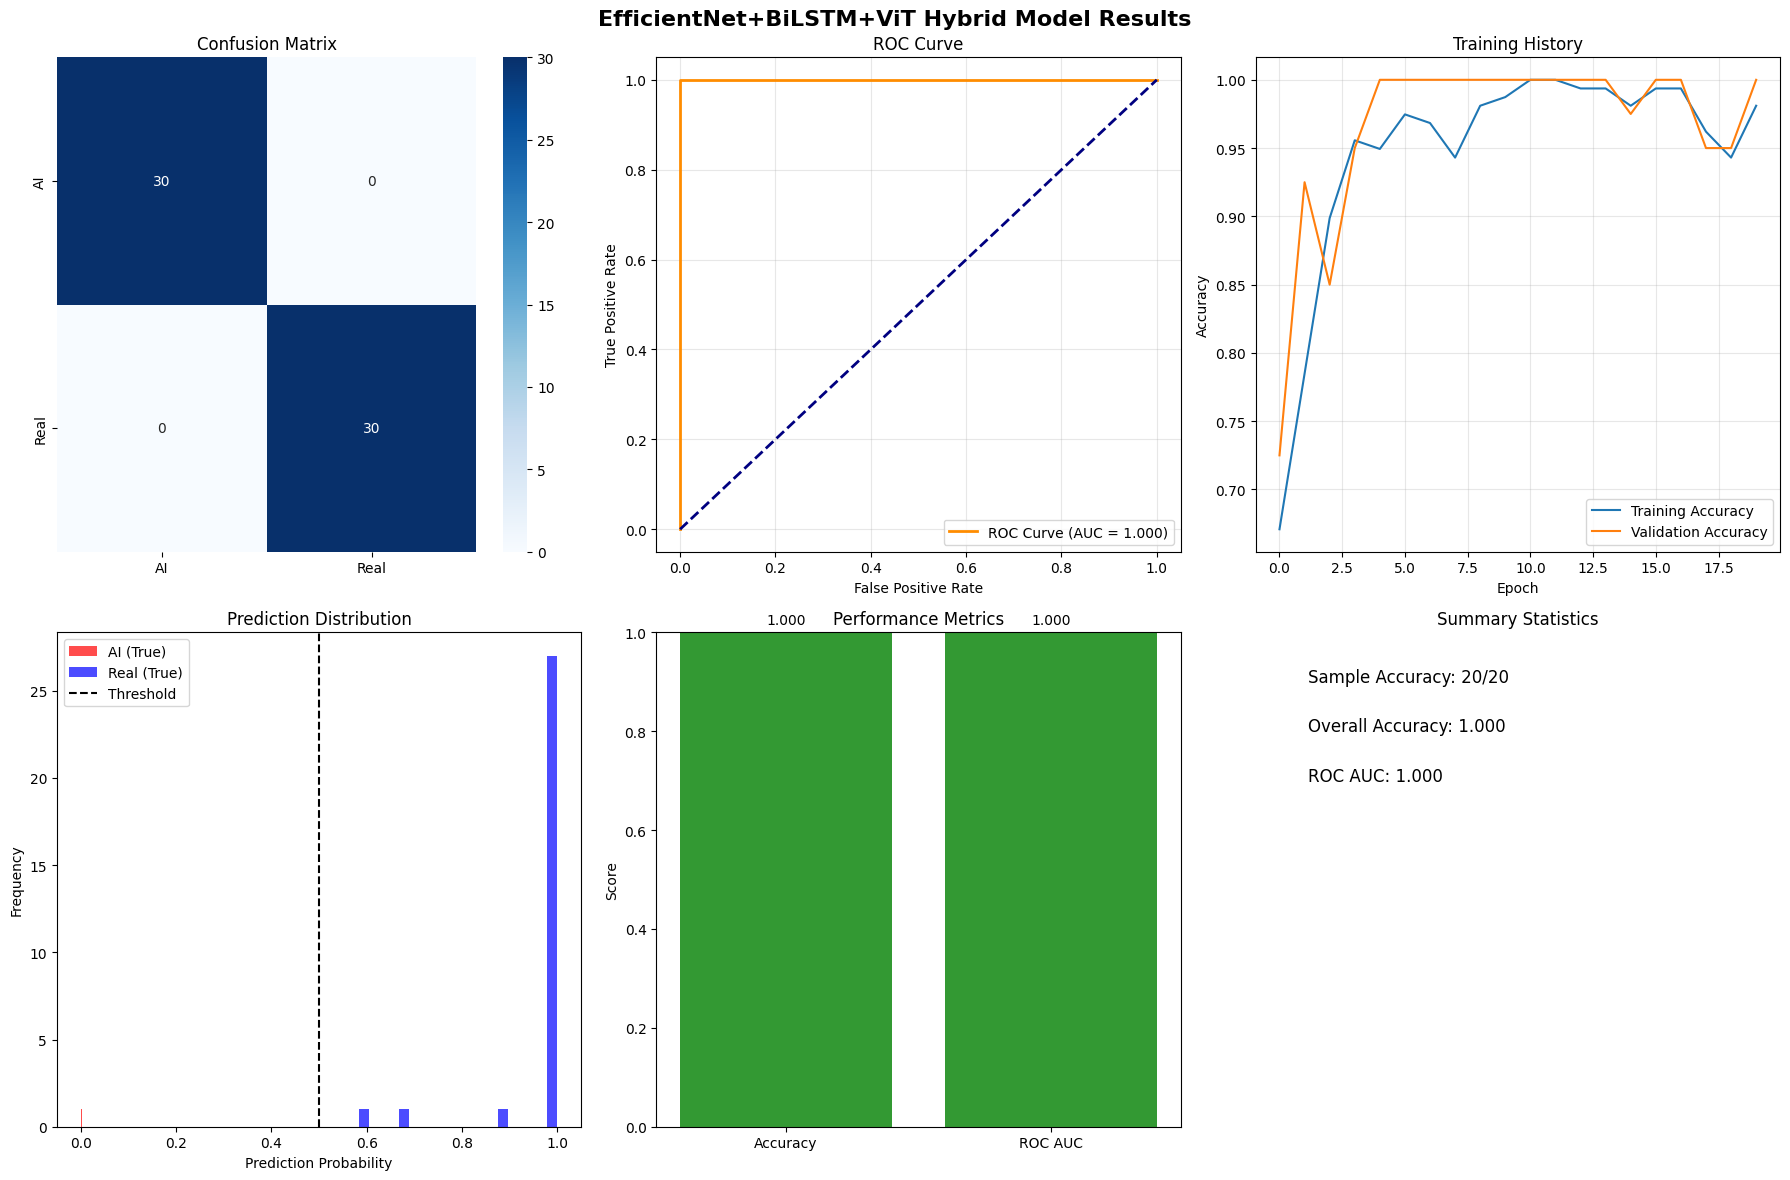


HYBRID MODEL EVALUATION RESULTS
              precision    recall  f1-score   support

          AI       1.00      1.00      1.00        30
        Real       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

Accuracy: 1.0000
ROC AUC Score: 1.0000


In [6]:
results = classifier.evaluate_hybrid_model()

In [7]:
!zip -r video_ai.zip /kaggle/working/

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/models_hybrid/ (stored 0%)
  adding: kaggle/working/models_hybrid/training_history.csv (deflated 68%)
  adding: kaggle/working/models_hybrid/best_efficientnet_bilstm_vit_model.h5 (deflated 8%)
  adding: kaggle/working/plots_hybrid/ (stored 0%)
  adding: kaggle/working/plots_hybrid/hybrid_evaluation.png (deflated 22%)
  adding: kaggle/working/features_hybrid/ (stored 0%)
  adding: kaggle/working/features_hybrid/y_labels.npy (deflated 95%)
  adding: kaggle/working/features_hybrid/X_features.npy (deflated 8%)


In [10]:
from IPython.display  import FileLink
FileLink(r'video_ai.zip')

/kaggle/working/video_ai.zip